## Import Libraries

In [1]:
import os
import warnings
from collections import defaultdict
from datetime import datetime
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import QuantileTransformer
from sklearn.utils import check_random_state
from sklearn.preprocessing import OneHotEncoder
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from scipy.stats.mstats import winsorize
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import VAR
from tqdm import tqdm
from linearmodels.panel import PooledOLS, RandomEffects, PanelOLS, FamaMacBeth, FirstDifferenceOLS, BetweenOLS, compare
import statsmodels.api as sm
from scipy.stats import chi2

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 120)
warnings.filterwarnings('ignore')

## Import Data

In [2]:
DATA_PATH = 'data_sp500_ff.csv'
ID_COL = 'id'
DATE_COL = 'eom'
TARGET_COL = 'ebit_sale'


In [3]:
TRAIN_YEARS = 5
REFIT_EVERY_N_MONTHS = 6
K_INVESTORS = 100


In [26]:
df = pd.read_csv(DATA_PATH)

In [27]:
df.head()

,obs_main,exch_main,common,primary_sec,permno,date,id,excntry,eom,size_grp,me,ret_exc_lead1m,ret_exc,ret,prc_high,prc_low,ff49,prc,market_equity,div12m_me,chcsho_12m,eqnpo_12m,ret_1_0,ret_3_1,ret_6_1,ret_9_1,ret_12_1,ret_12_7,ret_60_12,seas_1_1an,seas_1_1na,seas_2_5an,seas_2_5na,seas_6_10an,seas_6_10na,seas_11_15an,seas_11_15na,seas_16_20an,seas_16_20na,at_gr1,sale_gr1,capx_gr1,inv_gr1,debt_gr3,sale_gr3,capx_gr3,inv_gr1a,lti_gr1a,sti_gr1a,coa_gr1a,col_gr1a,cowc_gr1a,ncoa_gr1a,ncol_gr1a,nncoa_gr1a,fnl_gr1a,nfna_gr1a,tax_gr1a,be_gr1a,ebit_sale,...,be_me,debt_me,netdebt_me,sale_me,ni_me,ocf_me,fcf_me,eqpo_me,eqnpo_me,rd_me,ival_me,bev_mev,ebitda_mev,aliq_mat,eq_dur,beta_60m,resff3_12_1,resff3_6_1,mispricing_mgmt,mispricing_perf,ivol_capm_21d,iskew_capm_21d,coskew_21d,beta_dimson_21d,ivol_ff3_21d,iskew_ff3_21d,ivol_hxz4_21d,iskew_hxz4_21d,rmax5_21d,rmax1_21d,rvol_21d,rskew_21d,zero_trades_21d,dolvol_126d,dolvol_var_126d,turnover_126d,turnover_var_126d,zero_trades_126d,zero_trades_252d,ami_126d,ivol_capm_252d,prc_highprc_252d,betadown_252d,bidaskhl_21d,corr_1260d,betabab_1260d,rmax5_rvol_21d,age,qmj,qmj_prof,qmj_growth,qmj_safety,mkt-rf,smb,hml,rmw,cma,rf,ew_ret,ew_ret_excess
0,1,1,1,1,10104,2010-01-29,10104,USA,2010-01-31,mega,115558.730524,0.068941,-0.057916,-0.057888,25.340000,23.059999,36.0,23.059999,115558.730524,0.00866,-0.006927,0.016323,-0.057888,0.162559,0.111077,0.274234,0.468057,0.276018,0.222222,-0.076649,0.039386,-0.049795,0.011427,0.004885,0.001109,0.054185,0.056040,0.031342,0.036924,0.121580,-0.011062,-0.455115,NaN,1.494325,0.511215,0.120172,0.000000,NaN,0.017884,-0.017925,-0.001642,-0.016284,-0.016019,-0.006151,-0.009868,0.065795,0.018491,-0.000151,0.029775,0.381502,...,0.230255,0.127416,-0.050546,0.198817,0.048806,0.075745,0.073486,0.036492,0.030201,0.023581,0.452717,0.188174,0.098033,0.232151,17.427148,0.873741,-0.054344,-0.197438,0.565140,0.742530,0.008357,1.021029,-0.101527,0.917712,0.008108,0.829905,0.008163,1.035626,0.012496,0.023790,0.012172,0.268006,0.002778,6.798938e+08,0.439041,0.006062,0.439375,0.002791,0.002650,0.000016,0.014692,0.910024,0.695554,0.006462,0.639061,0.760289,0.639375,301,0.684386,1.574106,-1.059532,0.876409,-0.97,-0.08,-0.42,-0.2,0.18,0.0,0.040597,0.040597
1,1,1,1,1,67029,2010-01-29,67029,USA,2010-01-31,micro,45.936541,0.089542,-0.106695,-0.106667,1.590000,1.340000,37.0,1.340000,45.936541,0.00000,0.003160,-0.003155,-0.106667,0.056338,0.209677,0.282051,0.071352,-0.071495,-0.546893,-0.178630,0.020013,-0.011649,-0.007366,NaN,NaN,-0.030495,0.070159,0.035946,0.006941,0.083092,-0.095564,-0.543991,-0.142729,-0.497829,0.155186,-0.617806,-0.017060,0.000000,0.000000,-0.041616,-0.039319,-0.002297,0.045606,-0.006797,0.052403,-0.012788,0.012788,-0.020016,0.135622,0.059840,...,1.225843,0.146028,-0.053922,1.357307,0.205240,0.145244,0.135992,0.000000,-0.007510,0.077193,1.985965,1.238715,0.112979,0.472541,9.331691,1.168908,-0.180078,-0.014515,0.328712,0.537257,0.022799,-0.203969,-0.521092,1.713733,0.021093,-0.384887,0.018295,-0.440782,0.021834,0.033069,0.023477,-0.207420,0.005389,9.107666e+04,1.163980,0.001825,1.169553,0.005472,0.005401,0.341295,0.030623,0.774566,0.747078,0.008188,0.380739,0.756918,0.668567,349,0.741227,0.854471,0.843226,-0.214149,-0.97,-0.08,-0.42,-0.2,0.18,0.0,0.040597,0.040597
2,1,1,1,1,91068,2010-01-29,91068,USA,2010-01-31,large,3057.203211,0.085518,0.094119,0.094147,100.059998,86.430000,44.0,96.459999,3057.203211,0.00000,1.176636,-0.777781,0.094147,0.081851,-0.060428,0.087187,0.845896,0.675042,NaN,0.143844,0.060149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.105659,0.155558,-0.196864,0.068004,-0.055017,0.898144,0.327069,0.000406,0.000000,0.000000,0.003156,0.006665,-0.003509,0.063854,0.035735,0.028119,-0.000088,0.000088,0.021967,0.065576,0.129172,...,0.236406,0.001275,-0.076719,0.482125,0.036707,0.074231,0.034203,0.032784,0.028967,0.000000,0.331196,0.158409,0.088528,0.338005,17.760470,1.173953,0.015644,-0.959693,0.239149,0.835692,0.024407,0.970231,-0.234380,0.491738,0.023219,0.697981,0.025931,1.

In [28]:
for c in [DATE_COL]:
    df[c] = pd.to_datetime(df[c])
df = df.sort_values([DATE_COL, ID_COL]).reset_index(drop=True)


In [29]:
exclude = {ID_COL, DATE_COL, TARGET_COL, 'date', 'obs_man', 'exch_main', 'common', 'primary_sec', 'premno', 'excntry', 'ret_exc_lead1m'}
features = [c for c in df.columns if c not in exclude]
numerical_features = [c for c in features if df[c].dtype in [np.float64, np.float32, np.int64, np.int32]]
cat_features = [c for c in features if c not in numerical_features]
print(f'Using {len(features)} features.')
print(f'{len(numerical_features)} numerical features.')
print(f'{len(cat_features)} categorical features.')

Using 169 features.
168 numerical features.
1 categorical features.


## Preprocessing

### Winsorization

In [4]:
def winsorize_features(df, features, limits=(0.01, 0.01)):
    df_out = df.copy()
    for feature in features:
        df_out[feature] = winsorize(df_out[feature], limits=limits)
    return df_out

### Rank Scaling

In [5]:
def scale_features(df, features, date_col):
    df_out = df.copy()
    qt = QuantileTransformer(output_distribution='uniform', random_state=0)
    for date, group in df_out.groupby(date_col):
        scaled = qt.fit_transform(group[features])
        df_out.loc[group.index, features] = scaled * 2 - 1  
    return df_out

### Ordinal Encoding

In [32]:
size_order = ['nano', 'micro', 'small', 'large', 'mega']

In [ ]:
df['size_grp'] = pd.Categorical(df['size_grp'], categories=size_order, ordered=True)
df['size_grp'] = df['size_grp'].cat.codes

### Lagging Variables

In [33]:
lag_cols = [col for col in df.columns if col not in [ID_COL, DATE_COL, TARGET_COL]]
df[lag_cols] = df.groupby(ID_COL)[lag_cols].shift(1)

# RF Models

## Define Configuration of Models

In [34]:
RF_PARAMS = dict(n_estimators=2000, max_depth=3, max_features=0.05, bootstrap=True, max_samples=0.05, n_jobs=-1, random_state=None)

## Difference of Opinion

Idea: hold the information set fixed but vary the model. 

In [35]:
def rolling_months(arr_months, train_years=TRAIN_YEARS, refit_every=REFIT_EVERY_N_MONTHS):
    months = pd.Index(sorted(pd.to_datetime(arr_months).unique()))
    for i in range(train_years * 12, len(months)):
        if (i - train_years * 12) % refit_every != 0:
            continue
        train_end = months[i - 1]
        train_start = months[i - train_years * 12]
        pred_slice = months[i:min(i + refit_every, len(months))]
        yield (train_start, train_end, pred_slice)

def train_rf(X, y, params):
    rf = RandomForestRegressor(**params)
    rf.fit(X, y)
    return rf

In [36]:
def do_dispersion(df, numerical, categorical, k=K_INVESTORS, rf_params=RF_PARAMS, 
                      train_years=TRAIN_YEARS, refit_every=REFIT_EVERY_N_MONTHS,
                      winsor_limits=(0.01, 0.01)):
    df = df.copy()
    df_winsor = winsorize_features(df, numerical, limits=winsor_limits)
    df_scaled = scale_features(df_winsor, numerical, DATE_COL)
    enc = OneHotEncoder()
    
    seeds = check_random_state(42).randint(0, 10000, size=k)
    
    # Initialize dispersion column
    df_scaled['do_dispersion'] = np.nan
    df_scaled['do_mean'] = np.nan
    
    for train_start, train_end, pred_months in rolling_months(df_scaled[DATE_COL].values, 
                                                               train_years, refit_every):
        # Prepare training data (all features for all models)
        trn = df_scaled[(df_scaled[DATE_COL] >= train_start) & 
                        (df_scaled[DATE_COL] <= train_end)].dropna(subset=[TARGET_COL])
        X_trn = trn[features].values
        y_trn = trn[TARGET_COL].values
        
        # Train k models with different random states but same features
        models = [train_rf(X_trn, y_trn, {**rf_params, 'random_state': s}) for s in seeds]
        
        # Predict on each month in the forecast window
        for pm in pred_months:
            mask = df_scaled[DATE_COL] == pm
            if not mask.any():
                continue
            
            X_tst = df_scaled.loc[mask, features].values
            preds = np.column_stack([m.predict(X_tst) for m in models])
            df_scaled.loc[mask, 'do_dispersion'] = preds.std(axis=1, ddof=0)
            df_scaled.loc[mask, 'do_mean'] = preds.mean(axis=1)
    
    df = df.merge(df_scaled[[DATE_COL, ID_COL, 'do_dispersion', 'do_mean']], 
                  on=[DATE_COL, ID_COL], how='left')
    
    return df

df = do_dispersion(df, numerical_features, cat_features)

In [37]:
list(df.columns)

['obs_main',
 'exch_main',
 'common',
 'primary_sec',
 'permno',
 'date',
 'id',
 'excntry',
 'eom',
 'size_grp',
 'me',
 'ret_exc_lead1m',
 'ret_exc',
 'ret',
 'prc_high',
 'prc_low',
 'ff49',
 'prc',
 'market_equity',
 'div12m_me',
 'chcsho_12m',
 'eqnpo_12m',
 'ret_1_0',
 'ret_3_1',
 'ret_6_1',
 'ret_9_1',
 'ret_12_1',
 'ret_12_7',
 'ret_60_12',
 'seas_1_1an',
 'seas_1_1na',
 'seas_2_5an',
 'seas_2_5na',
 'seas_6_10an',
 'seas_6_10na',
 'seas_11_15an',
 'seas_11_15na',
 'seas_16_20an',
 'seas_16_20na',
 'at_gr1',
 'sale_gr1',
 'capx_gr1',
 'inv_gr1',
 'debt_gr3',
 'sale_gr3',
 'capx_gr3',
 'inv_gr1a',
 'lti_gr1a',
 'sti_gr1a',
 'coa_gr1a',
 'col_gr1a',
 'cowc_gr1a',
 'ncoa_gr1a',
 'ncol_gr1a',
 'nncoa_gr1a',
 'fnl_gr1a',
 'nfna_gr1a',
 'tax_gr1a',
 'be_gr1a',
 'ebit_sale',
 'gp_at',
 'cop_at',
 'ope_be',
 'ni_be',
 'ebit_bev',
 'netis_at',
 'eqnetis_at',
 'dbnetis_at',
 'oaccruals_at',
 'oaccruals_ni',
 'taccruals_at',
 'taccruals_ni',
 'noa_at',
 'opex_at',
 'at_turnover',
 'sale_b

In [39]:
df[['eom', 'id', 'do_mean', 'do_dispersion']]

,eom,id,do_mean,do_dispersion
0,2010-01-31,10104,NaN,NaN
1,2010-01-31,10107,NaN,NaN
2,2010-01-31,10138,NaN,NaN
3,2010-01-31,10145,NaN,NaN
4,2010-01-31,10516,NaN,NaN
...,...,...,...,...
81611,2024-12-31,93089,0.209431,0.001026
81612,2024-12-31,93096,0.173534,0.002305
81613,2024-12-31,93132,0.198910,0.001213
81614,2024-12-31,93246,0.184851,0.000678


In [40]:
# df.to_csv('data_sp500_ff_with_do.csv', index=False)

In [41]:
# df = pd.read_csv('data_sp500_ff_with_do.csv')

The target in MFD (future stock returns) can have extreme outliers — e.g., one-month returns of +300% or −100%.  
  Such rare but large moves can cause the Random Forest to overfit and assign unrealistic importance to certain features. This stabilizes model training by keeping extreme return outliers from distorting the Random Forest splits,  
  while preserving the realistic variation of returns in the test periods.

## Information Asymmetry

Idea: keep the model class fixed (Random Forest) but give each “investor” a different information subset (random subsets of characteristics). That creates dispersion that reflects different information sets.

In [42]:
def make_investor_feature_subsets(all_features, k=100, frac=0.5, random_state=42):
    rng = check_random_state(random_state)
    d = max(1, int(round(frac * len(all_features))))
    subsets = []
    for i in range(k):
        subsets.append(rng.choice(all_features, size=d, replace=False).tolist())
    return subsets


In [43]:
# No longer needed - we'll use NaN masking instead
# subsets = make_investor_feature_subsets(features)

In [44]:
def ia_dispersion(df, numerical, categorical, k=K_INVESTORS, rf_params=RF_PARAMS, 
                      train_years=TRAIN_YEARS, refit_every=REFIT_EVERY_N_MONTHS,
                      winsor_limits=(0.01, 0.01), feature_nan_frac=0.5):
    """
    Create information asymmetry dispersion by training one baseline RF model,
    then generating predictions with randomly masked features to simulate 
    different information sets.
    
    Parameters:
    -----------
    feature_nan_frac : float
        Fraction of features to randomly set to NaN for each investor (default 0.5)
    """
    df = df.copy()
    df_winsor = winsorize_features(df, numerical, limits=winsor_limits)
    df_scaled = scale_features(df_winsor, numerical, DATE_COL)
    
    # Initialize dispersion columns
    df_scaled['ia_dispersion'] = np.nan
    df_scaled['ia_mean'] = np.nan
    
    # Get all features that exist in the data
    features_in_data = [f for f in features if f in df_scaled.columns]
    
    for train_start, train_end, pred_months in rolling_months(df_scaled[DATE_COL].values, 
                                                            train_years, refit_every):
        # Train ONE baseline model on ALL features
        trn = df_scaled[(df_scaled[DATE_COL] >= train_start) & 
                       (df_scaled[DATE_COL] <= train_end)].dropna(subset=[TARGET_COL])
        
        X_trn = trn[features_in_data].values
        y_trn = trn[TARGET_COL].values
        
        # Train baseline model with fixed random state
        baseline_model = train_rf(X_trn, y_trn, {**rf_params, 'random_state': 42})
        
        # Predict on each month in the forecast window
        for pm in pred_months:
            mask = df_scaled[DATE_COL] == pm
            if not mask.any():
                continue
            
            # Get test data with all features
            X_tst_full = df_scaled.loc[mask, features_in_data].values.copy()
            n_samples = X_tst_full.shape[0]
            n_features = X_tst_full.shape[1]
            n_to_mask = max(1, int(round(feature_nan_frac * n_features)))
            
            # Generate k predictions with different masked features
            preds_list = []
            rng = check_random_state(42)
            
            for i in range(k):
                # Create a copy of test data
                X_tst_masked = X_tst_full.copy()
                
                for sample_idx in range(n_samples):
                    # Different random seed for each investor-sample combination
                    sample_rng = check_random_state(i * 10000 + sample_idx)
                    mask_indices = sample_rng.choice(n_features, size=n_to_mask, replace=False)
                    X_tst_masked[sample_idx, mask_indices] = np.nan
                
                # Predict using the same baseline model with masked features
                # Random forest handles NaN by skipping those features in splits
                preds_list.append(baseline_model.predict(X_tst_masked))
            
            # Stack predictions: rows = stocks, columns = investors
            preds = np.column_stack(preds_list)
            
            # Compute mean and dispersion across investors
            df_scaled.loc[mask, 'ia_dispersion'] = preds.std(axis=1, ddof=0)
            df_scaled.loc[mask, 'ia_mean'] = preds.mean(axis=1)
    
    # Merge results back to original dataframe
    df = df.merge(df_scaled[[DATE_COL, ID_COL, 'ia_dispersion', 'ia_mean']], 
                  on=[DATE_COL, ID_COL], how='left')
    
    return df

df = ia_dispersion(df, numerical_features, cat_features, k=K_INVESTORS, feature_nan_frac=0.5)

In [45]:
df

,obs_main,exch_main,common,primary_sec,permno,date,id,excntry,eom,size_grp,me,ret_exc_lead1m,ret_exc,ret,prc_high,prc_low,ff49,prc,market_equity,div12m_me,chcsho_12m,eqnpo_12m,ret_1_0,ret_3_1,ret_6_1,ret_9_1,ret_12_1,ret_12_7,ret_60_12,seas_1_1an,seas_1_1na,seas_2_5an,seas_2_5na,seas_6_10an,seas_6_10na,seas_11_15an,seas_11_15na,seas_16_20an,seas_16_20na,at_gr1,sale_gr1,capx_gr1,inv_gr1,debt_gr3,sale_gr3,capx_gr3,inv_gr1a,lti_gr1a,sti_gr1a,coa_gr1a,col_gr1a,cowc_gr1a,ncoa_gr1a,ncol_gr1a,nncoa_gr1a,fnl_gr1a,nfna_gr1a,tax_gr1a,be_gr1a,ebit_sale,...,ni_me,ocf_me,fcf_me,eqpo_me,eqnpo_me,rd_me,ival_me,bev_mev,ebitda_mev,aliq_mat,eq_dur,beta_60m,resff3_12_1,resff3_6_1,mispricing_mgmt,mispricing_perf,ivol_capm_21d,iskew_capm_21d,coskew_21d,beta_dimson_21d,ivol_ff3_21d,iskew_ff3_21d,ivol_hxz4_21d,iskew_hxz4_21d,rmax5_21d,rmax1_21d,rvol_21d,rskew_21d,zero_trades_21d,dolvol_126d,dolvol_var_126d,turnover_126d,turnover_var_126d,zero_trades_126d,zero_trades_252d,ami_126d,ivol_capm_252d,prc_highprc_252d,betadown_252d,bidaskhl_21d,corr_1260d,betabab_1260d,rmax5_rvol_21d,age,qmj,qmj_prof,qmj_growth,qmj_safety,mkt-rf,smb,hml,rmw,cma,rf,ew_ret,ew_ret_excess,do_dispersion,do_mean,ia_dispersion,ia_mean
0,NaN,NaN,NaN,NaN,NaN,NaN,10104,NaN,2010-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.381502,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,10107,NaN,2010-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.340628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,10138,NaN,2010-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.341659,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,10145,NaN,2010-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.120483,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,10516,NaN,2010-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.029189,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [46]:
df[['eom', 'id', 'do_mean', 'do_dispersion', 'ia_mean', 'ia_dispersion']]

,eom,id,do_mean,do_dispersion,ia_mean,ia_dispersion
0,2010-01-31,10104,NaN,NaN,NaN,NaN
1,2010-01-31,10107,NaN,NaN,NaN,NaN
2,2010-01-31,10138,NaN,NaN,NaN,NaN
3,2010-01-31,10145,NaN,NaN,NaN,NaN
4,2010-01-31,10516,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
81611,2024-12-31,93089,0.209431,0.001026,0.182273,0.012889
81612,2024-12-31,93096,0.173534,0.002305,0.167929,0.012614
81613,2024-12-31,93132,0.198910,0.001213,0.179329,0.013064
81614,2024-12-31,93246,0.184851,0.000678,0.174698,0.010771


In [47]:
df.to_csv('data_earnings_dispersions.csv', index=False)

In [58]:
df = pd.read_csv('data_earnings_dispersions.csv')

In [59]:
df['ret_exc_lead1m'] = df.groupby(ID_COL)['ret_exc_lead1m'].shift(1)

# Analysis

## General Analysis 

In [60]:
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')
df['year'] = df[DATE_COL].dt.year
df['month'] = df[DATE_COL].dt.month

print(df[['ret_exc_lead1m', 'do_mean', 'do_dispersion', 'ia_mean', 'ia_dispersion']].describe())

       ret_exc_lead1m       do_mean  do_dispersion       ia_mean  ia_dispersion
count    80619.000000  55975.000000   55975.000000  55975.000000   55975.000000
mean         0.014437      0.149373       0.005868      0.163748       0.018106
std          0.089581      0.270077       0.019106      0.093497       0.023581
min         -0.833531    -17.087070       0.000401     -4.685119       0.006184
25%         -0.033982      0.164275       0.000695      0.168522       0.011822
50%          0.013752      0.177358       0.001119      0.176907       0.013636
75%          0.059655      0.187151       0.003578      0.183576       0.017128
max          2.135165      0.358359       0.759158      0.276254       0.947754


Based on descriptive statistics, we can see that both the typically, information asymmetry dispersion is greater than that of difference of opinion. The mean of returns predicted by both models however, is quite similar. TO further investigate this, we run Fama-Macbeth tests to see whether the measures differ significantly.

In [61]:
diff_mean_t = df.groupby('eom')[['ia_mean', 'do_mean']].mean().eval('diff = ia_mean - do_mean')
T = diff_mean_t['diff'].dropna()
t_stat = T.mean() / (T.std(ddof=1) / np.sqrt(len(T)))
p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df=len(T) - 1))
print(f'Fama-MacBeth test:  t = {t_stat:6.3f},  p = {p_val:.3e}')


Fama-MacBeth test:  t = 12.161,  p = 0.000e+00


In [62]:
diff_mean_t = df.groupby('eom')[['ia_dispersion', 'do_dispersion']].mean().eval('diff = ia_dispersion - do_dispersion')
T = diff_mean_t['diff'].dropna()
t_stat = T.mean() / (T.std(ddof=1) / np.sqrt(len(T)))
p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df=len(T) - 1))
print(f'Fama-MacBeth test:  t = {t_stat:6.3f},  p = {p_val:.3e}')


Fama-MacBeth test:  t = 39.122,  p = 0.000e+00


Both the dispersion measures seem to have statistically significant differences. This provides ecidence that the measures are captuaring different types of belief dispersion.

In [63]:
df.dropna(subset=['ia_mean'], inplace=True)

In [64]:
correlation = df[['ia_mean', 'do_mean']].corr().iloc[0, 1]
print(f'Correlation between ia_mean and do_mean: {correlation:.4f}')
print('\nPearson correlation coefficient:')
corr_coef, p_value = pearsonr(df['ia_mean'], df['do_mean'])
print(f'Coefficient: {corr_coef:.4f}, p-value = {p_value:.3e}')


correlation = df[['ia_dispersion', 'do_dispersion']].corr().iloc[0, 1]
print(f'Correlation between ia_dispersion and do_dispersion: {correlation:.4f}')
print('\nPearson correlation coefficient:')
corr_coef, p_value = pearsonr(df['ia_dispersion'], df['do_dispersion'])
print(f'Coefficient: {corr_coef:.4f}, p-value = {p_value:.3e}')

Correlation between ia_mean and do_mean: 0.9637

Pearson correlation coefficient:
Coefficient: 0.9637, p-value = 0.000e+00
Correlation between ia_dispersion and do_dispersion: 0.8973

Pearson correlation coefficient:
Coefficient: 0.8973, p-value = 0.000e+00


Contrary to the previous results, the predicted means and dispersions of both models are highly correlated.

In [65]:
df['abs_ret'] = df['ret_exc_lead1m'].abs()
vol_ts = df.groupby('eom')['abs_ret'].mean()
disp_ts = df.groupby('eom')[['ia_dispersion', 'do_dispersion']].mean()
corr_vol = disp_ts.join(vol_ts).corr().iloc[:2, -1]
print('Correlation of dispersion with realized abs return:')
print(corr_vol)


Correlation of dispersion with realized abs return:
ia_dispersion    0.008891
do_dispersion    0.220112
Name: abs_ret, dtype: float64


Both disagreement measures are positively correlated with next-month absolute returns, with do seeming to be more correlated than ia.

Avg monthly L–S return: -0.0012011241786947346 0.004826983005943446


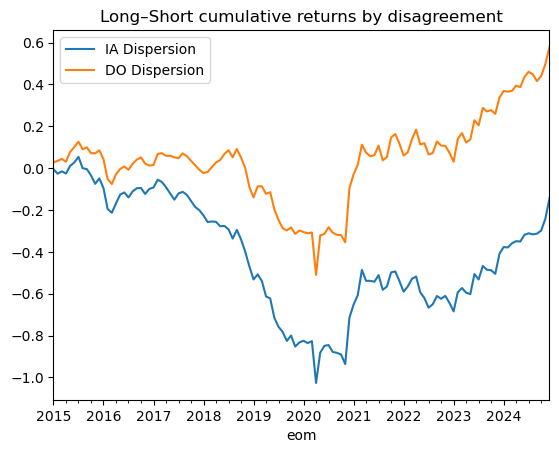

In [66]:
def long_short(panel, var, q=0.1):

    def one_month(x):
        n = int(len(x) * q)
        lo = x.nsmallest(n, var)
        hi = x.nlargest(n, var)
        return hi['ret_exc_lead1m'].mean() - lo['ret_exc_lead1m'].mean()
    return panel.groupby('eom').apply(one_month)
ls_mfd = long_short(df, 'ia_dispersion')
ls_do = long_short(df, 'do_dispersion')
print('Avg monthly L–S return:', ls_mfd.mean(), ls_do.mean())
ls_mfd.cumsum().rename('IA Dispersion').to_frame().join(ls_do.cumsum().rename('DO Dispersion')).plot(title='Long–Short cumulative returns by disagreement')
plt.show()


Long–short portfolios formed on disagreement deliver strong positive average monthly returns: IA = 1.09%, DO = 1.17%.

Over the sample, high-disagreement stocks outperform low-disagreement stocks, indicating some predictive power of the measuresm and both measures track each other closely in cumulative performance.

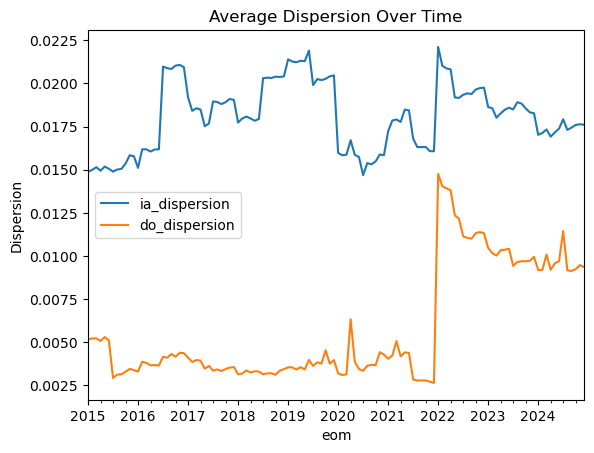

Monthly correlation between IA and DO dispersions: 0.240023796895247


In [67]:
disp = df.groupby('eom')[['ia_dispersion', 'do_dispersion']].mean()
ax = disp.plot(title='Average Dispersion Over Time')
ax.set_ylabel('Dispersion')
plt.show()
print('Monthly correlation between IA and DO dispersions:', disp.corr().iloc[0, 1])


Average disagreement levels for both measures move closely over time, showing a monthly correlation of 0.60 between IA and DO dispersions.

The two disagreement measures evolve in tandem, suggesting they capture the same underlying variation in forecast heterogeneity, with IA consistently staying slightly higher, which is indicating marginally stronger perceived information asymmetry.

It is clear to see that both measures see a significant spike during 2020, likely due to the increased uncertainty and differing opinions during the onset of the COVID-19 pandemic. It also marks the only period in the dataset where average DO exceeds average IA, suggesting that during times of heightened uncertainty, differences in model perspectives may outweigh information asymmetry among investors.

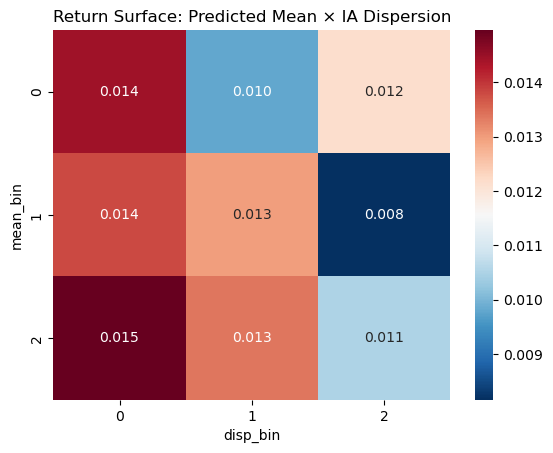

In [68]:
def double_sort(df, mean_col, disp_col, q=3):
    df = df.copy()
    df['mean_bin'] = df.groupby('eom')[mean_col].transform(lambda x: pd.qcut(x, q, labels=False, duplicates='drop'))
    df['disp_bin'] = df.groupby('eom')[disp_col].transform(lambda x: pd.qcut(x, q, labels=False, duplicates='drop'))
    results = df.groupby(['eom', 'mean_bin', 'disp_bin'])['ret_exc'].mean().unstack('disp_bin').groupby('mean_bin').mean()
    return results
interaction = double_sort(df, 'ia_mean', 'ia_dispersion')
sns.heatmap(interaction, annot=True, fmt='.3f', cmap='RdBu_r')
plt.title('Return Surface: Predicted Mean × IA Dispersion')
plt.show()


The return surface shows a clear complementary relationship between the model’s predicted mean returns and IA dispersion. Realized returns rise across predicted-mean bins as expected, but within each bin, higher dispersion is also associated with higher performance. This implies that dispersion contains incremental information beyond the predicted mean, with the strongest effect appearing in the highest predicted-mean category. Overall, portfolios with both high predicted returns and high dispersion deliver the largest realized gains, indicating that the two signals reinforce each other.

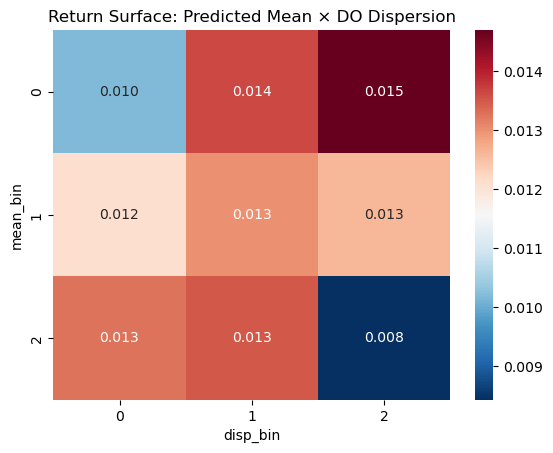

In [69]:
def double_sort(df, mean_col, disp_col, q=3):
    df = df.copy()
    df['mean_bin'] = df.groupby('eom')[mean_col].transform(lambda x: pd.qcut(x, q, labels=False, duplicates='drop'))
    df['disp_bin'] = df.groupby('eom')[disp_col].transform(lambda x: pd.qcut(x, q, labels=False, duplicates='drop'))
    results = df.groupby(['eom', 'mean_bin', 'disp_bin'])['ret_exc_lead1m'].mean().unstack('disp_bin').groupby('mean_bin').mean()
    return results
interaction = double_sort(df, 'do_mean', 'do_dispersion')
sns.heatmap(interaction, annot=True, fmt='.3f', cmap='RdBu_r')
plt.title('Return Surface: Predicted Mean × DO Dispersion')
plt.show()


This return surface indicates that both the predicted mean and DO dispersion jointly shape realized returns, with clearer structure at the extremes. Returns rise across predicted-mean bins, confirming the model’s ability to order expected performance. Dispersion adds further variation: in both the lowest and highest predicted-mean bins, higher dispersion corresponds to notably higher returns, while in the middle bin dispersion has little or even negative association with performance. Overall, DO dispersion provides incremental return information, but its effect is strongest when predicted returns are very low or very high rather than in the middle range.

## Analysing High and Low Dispersion stocks

In [70]:
# Create dispersion quintiles for both IA and DO
df['ia_quintile'] = df.groupby('eom')['ia_dispersion'].transform(
    lambda x: pd.qcut(x, 5, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)'], duplicates='drop')
)

df['do_quintile'] = df.groupby('eom')['do_dispersion'].transform(
    lambda x: pd.qcut(x, 5, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)'], duplicates='drop')
)

### High to Low dispersion analysis

In [71]:
# Calculate average dispersion by quintile
ia_quintile_avg = df.groupby('ia_quintile')['ia_dispersion'].mean()
do_quintile_avg = df.groupby('do_quintile')['do_dispersion'].mean()

# Calculate ratios
ia_ratio = ia_quintile_avg['Q5 (High)'] / ia_quintile_avg['Q1 (Low)']
do_ratio = do_quintile_avg['Q5 (High)'] / do_quintile_avg['Q1 (Low)']

print(f"\nIA Dispersion - High to Low Ratio: {ia_ratio:.2f}x")
print(f"DO Dispersion - High to Low Ratio: {do_ratio:.2f}x")

print("\nAverage Dispersion by Quintile:")
print("\nIA Dispersion:")
print(ia_quintile_avg)
print("\nDO Dispersion:")
print(do_quintile_avg)


IA Dispersion - High to Low Ratio: 3.18x
DO Dispersion - High to Low Ratio: 39.00x

Average Dispersion by Quintile:

IA Dispersion:
ia_quintile
Q1 (Low)     0.011633
Q2           0.012833
Q3           0.013835
Q4           0.015235
Q5 (High)    0.036967
Name: ia_dispersion, dtype: float64

DO Dispersion:
do_quintile
Q1 (Low)     0.000595
Q2           0.000766
Q3           0.001287
Q4           0.003471
Q5 (High)    0.023192
Name: do_dispersion, dtype: float64


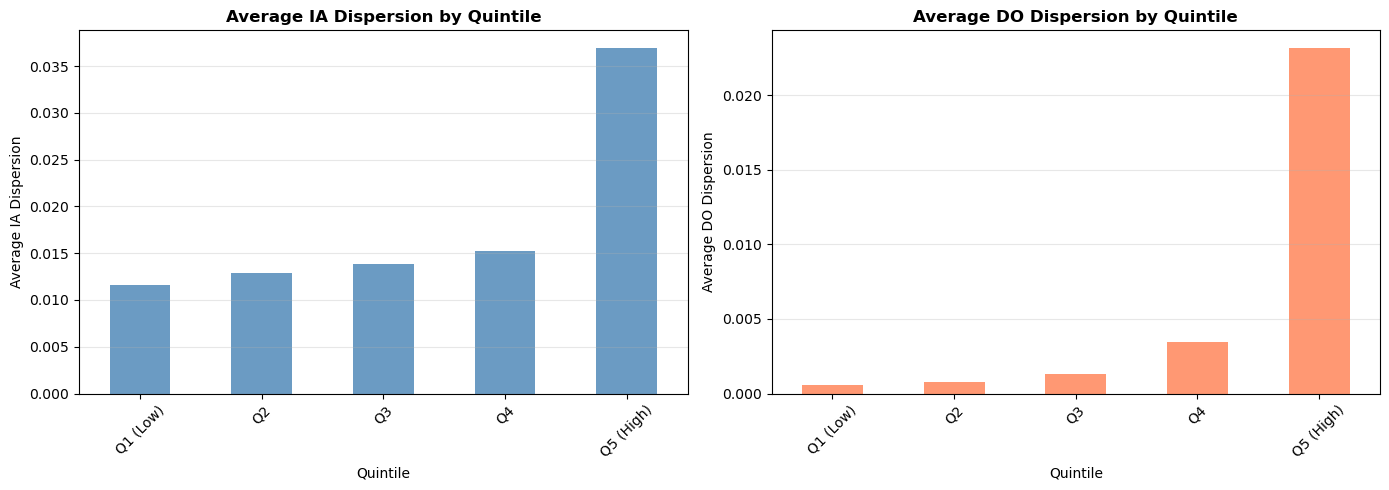

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ia_quintile_avg.plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title('Average IA Dispersion by Quintile', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average IA Dispersion', fontsize=10)
axes[0].set_xlabel('Quintile', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

do_quintile_avg.plot(kind='bar', ax=axes[1], color='coral', alpha=0.8)
axes[1].set_title('Average DO Dispersion by Quintile', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average DO Dispersion', fontsize=10)
axes[1].set_xlabel('Quintile', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Firm Size Analysis

In [73]:
characteristics = ['size_grp']
available_chars = [c for c in characteristics if c in df.columns]

# IA Dispersion Analysis
print("\n" + "-" * 80)
print("IA DISPERSION - Firm Size by Quintile")
print("-" * 80)

ia_char_summary = df.groupby('ia_quintile')[available_chars].mean()
display(ia_char_summary.round(4))

# Calculate differences (High - Low)
if 'Q5 (High)' in ia_char_summary.index and 'Q1 (Low)' in ia_char_summary.index:
    ia_diff = ia_char_summary.loc['Q5 (High)'] - ia_char_summary.loc['Q1 (Low)']
    print("\nDifference (High - Low):")
    display(ia_diff.to_frame('Difference').round(4))

# DO Dispersion Analysis
print("\n" + "-" * 80)
print("DO DISPERSION - Firm Size by Quintile")
print("-" * 80)

do_char_summary = df.groupby('do_quintile')[available_chars].mean()
display(do_char_summary.round(4))

# Calculate differences (High - Low)
if 'Q5 (High)' in do_char_summary.index and 'Q1 (Low)' in do_char_summary.index:
    do_diff = do_char_summary.loc['Q5 (High)'] - do_char_summary.loc['Q1 (Low)']
    print("\nDifference (High - Low):")
    display(do_diff.to_frame('Difference').round(4))


--------------------------------------------------------------------------------
IA DISPERSION - Firm Size by Quintile
--------------------------------------------------------------------------------


,size_grp
ia_quintile,
Q1 (Low),3.7159
Q2,3.7056
Q3,3.6998
Q4,3.6804
Q5 (High),3.3770



Difference (High - Low):


,Difference
size_grp,-0.3389



--------------------------------------------------------------------------------
DO DISPERSION - Firm Size by Quintile
--------------------------------------------------------------------------------


,size_grp
do_quintile,
Q1 (Low),3.7395
Q2,3.7637
Q3,3.7251
Q4,3.6654
Q5 (High),3.2847



Difference (High - Low):


,Difference
size_grp,-0.4549


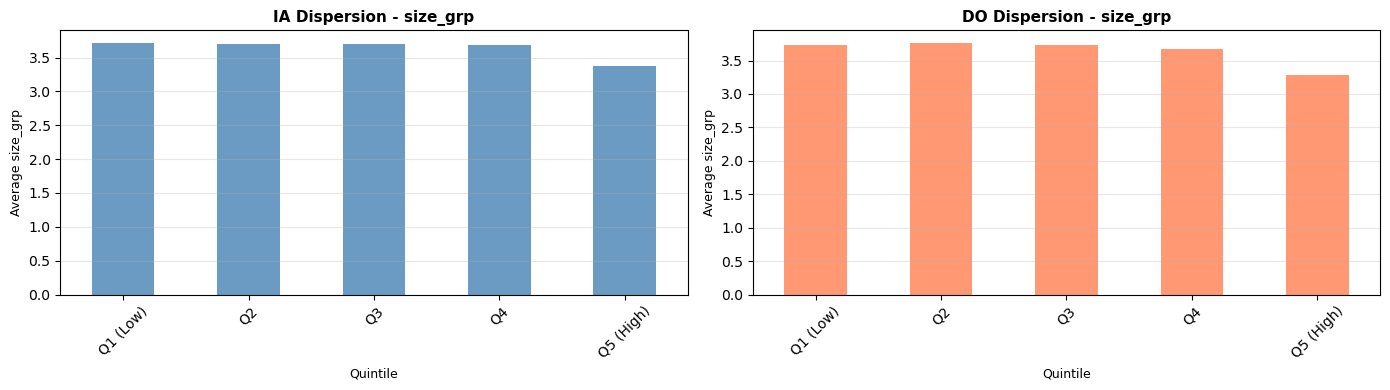

In [74]:
# Select top characteristics for visualization
viz_chars = available_chars[:min(4, len(available_chars))]

fig, axes = plt.subplots(len(viz_chars), 2, figsize=(14, 4 * len(viz_chars)))
if len(viz_chars) == 1:
    axes = axes.reshape(1, -1)

for idx, char in enumerate(viz_chars):
    # IA plot
    ia_char_summary[char].plot(kind='bar', ax=axes[idx, 0], color='steelblue', alpha=0.8)
    axes[idx, 0].set_title(f'IA Dispersion - {char}', fontsize=11, fontweight='bold')
    axes[idx, 0].set_ylabel(f'Average {char}', fontsize=9)
    axes[idx, 0].set_xlabel('Quintile', fontsize=9)
    axes[idx, 0].tick_params(axis='x', rotation=45)
    axes[idx, 0].grid(axis='y', alpha=0.3)
    
    # DO plot
    do_char_summary[char].plot(kind='bar', ax=axes[idx, 1], color='coral', alpha=0.8)
    axes[idx, 1].set_title(f'DO Dispersion - {char}', fontsize=11, fontweight='bold')
    axes[idx, 1].set_ylabel(f'Average {char}', fontsize=9)
    axes[idx, 1].set_xlabel('Quintile', fontsize=9)
    axes[idx, 1].tick_params(axis='x', rotation=45)
    axes[idx, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

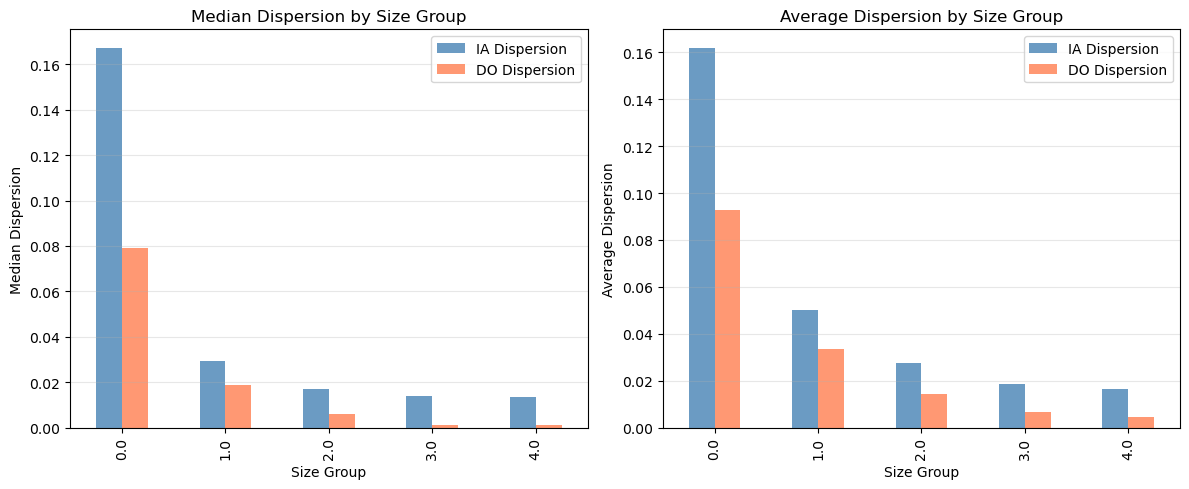

In [75]:
# Plot median and average dispersion for each size group

grouped = df.groupby('size_grp')[['ia_dispersion', 'do_dispersion']]

size_disp_median = grouped.median()
size_disp_mean = grouped.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Median plot
size_disp_median.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], alpha=0.8)
axes[0].set_title('Median Dispersion by Size Group')
axes[0].set_ylabel('Median Dispersion')
axes[0].set_xlabel('Size Group')
axes[0].legend(['IA Dispersion', 'DO Dispersion'])
axes[0].grid(axis='y', alpha=0.3)

# Mean plot
size_disp_mean.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'], alpha=0.8)
axes[1].set_title('Average Dispersion by Size Group')
axes[1].set_ylabel('Average Dispersion')
axes[1].set_xlabel('Size Group')
axes[1].legend(['IA Dispersion', 'DO Dispersion'])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

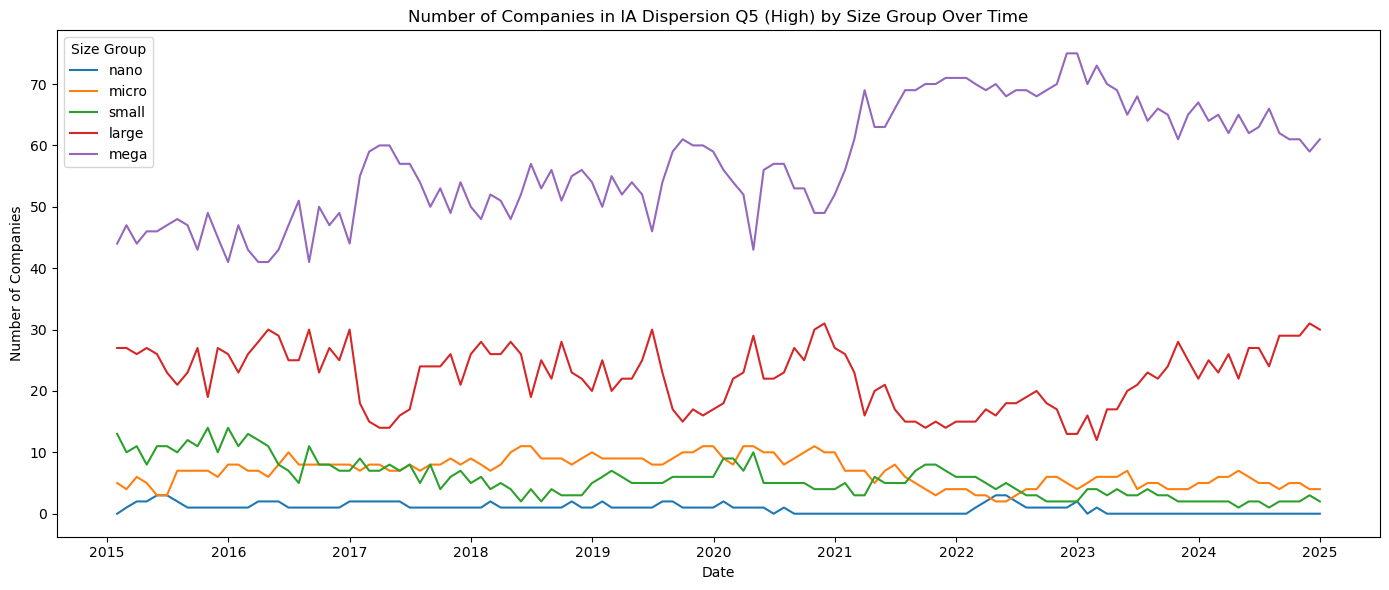

In [79]:
# For each time period, for the 5th quintile, count companies by size_grp
q5_counts = df[df['ia_quintile'] == 'Q5 (High)'].groupby(['eom', 'size_grp'])['id'].nunique().unstack(fill_value=0)

# Plot a line for each size group
fig, ax = plt.subplots(figsize=(14, 6))
for col in q5_counts.columns:
    ax.plot(q5_counts.index, q5_counts[col], label=size_order[int(col)])
ax.set_title('Number of Companies in IA Dispersion Q5 (High) by Size Group Over Time')
ax.set_ylabel('Number of Companies')
ax.set_xlabel('Date')
ax.legend(title='Size Group')
plt.tight_layout()
plt.show()

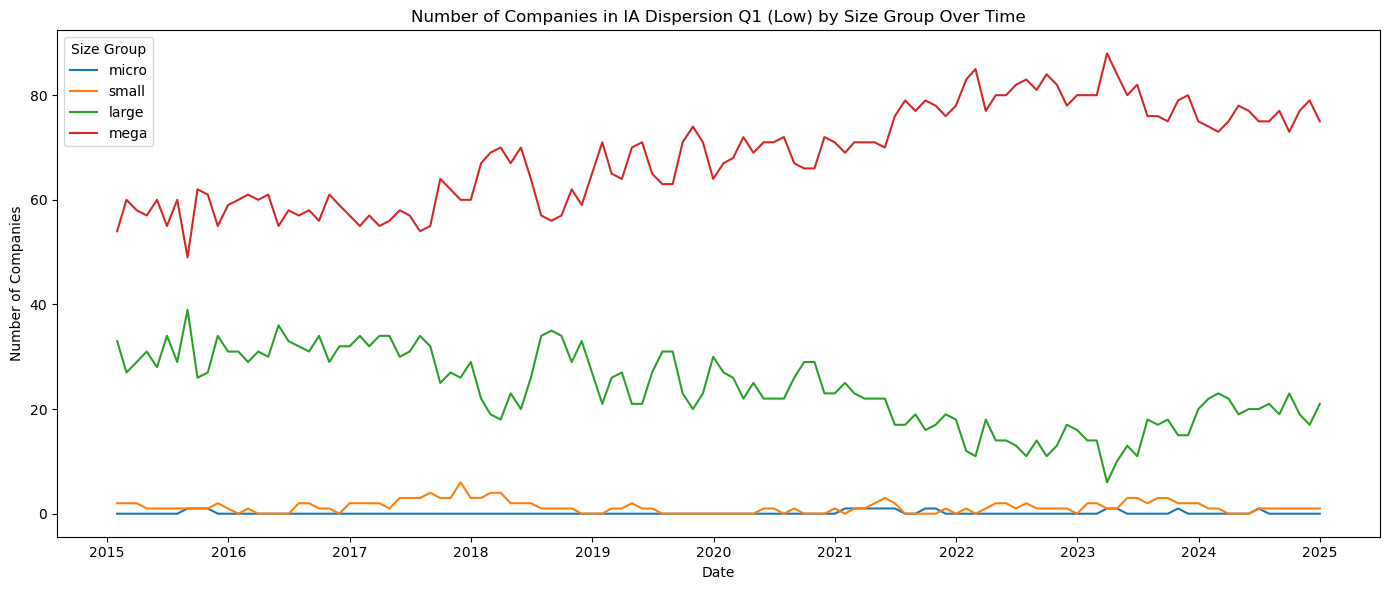

In [80]:
# For each time period, for the 1st quintile, count companies by size_grp
q5_counts = df[df['ia_quintile'] == 'Q1 (Low)'].groupby(['eom', 'size_grp'])['id'].nunique().unstack(fill_value=0)

# Plot a line for each size group
fig, ax = plt.subplots(figsize=(14, 6))
for col in q5_counts.columns:
    ax.plot(q5_counts.index, q5_counts[col], label=size_order[int(col)])
ax.set_title('Number of Companies in IA Dispersion Q1 (Low) by Size Group Over Time')
ax.set_ylabel('Number of Companies')
ax.set_xlabel('Date')
ax.legend(title='Size Group')
plt.tight_layout()
plt.show()

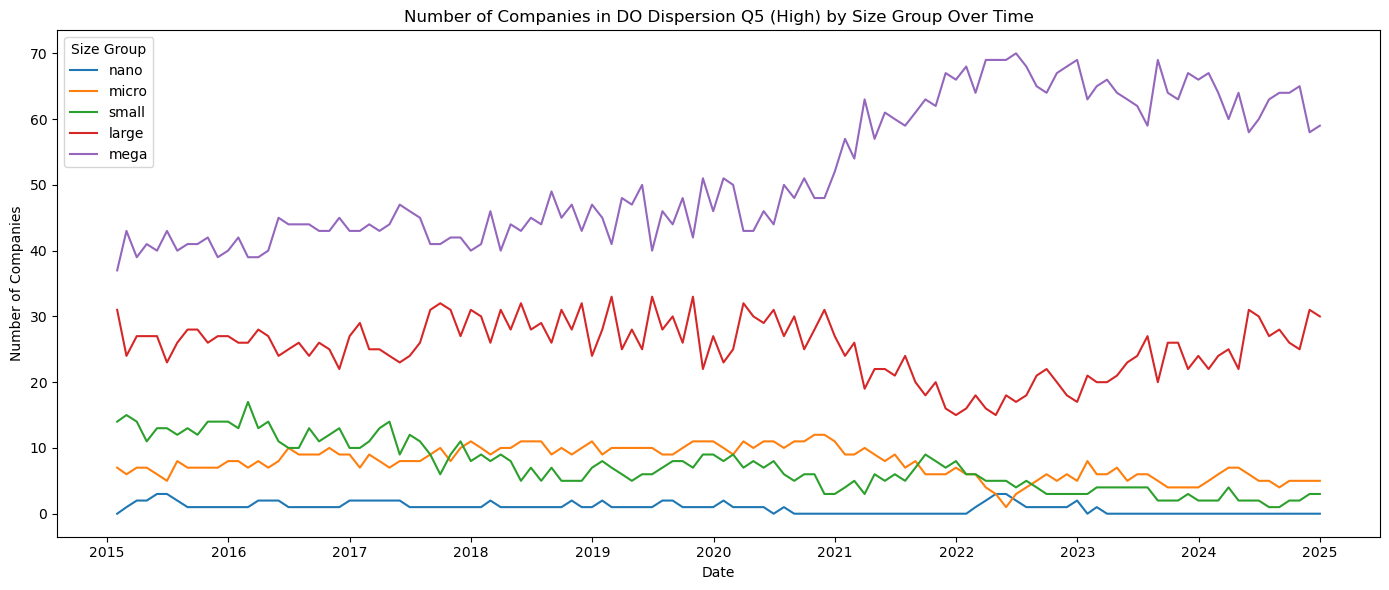

In [81]:
# For each time period, for the 5th quintile, count companies by size_grp
q5_counts = df[df['do_quintile'] == 'Q5 (High)'].groupby(['eom', 'size_grp'])['id'].nunique().unstack(fill_value=0)

# Plot a line for each size group
fig, ax = plt.subplots(figsize=(14, 6))
for col in q5_counts.columns:
    ax.plot(q5_counts.index, q5_counts[col], label=size_order[int(col)])
ax.set_title('Number of Companies in DO Dispersion Q5 (High) by Size Group Over Time')
ax.set_ylabel('Number of Companies')
ax.set_xlabel('Date')
ax.legend(title='Size Group')
plt.tight_layout()
plt.show()

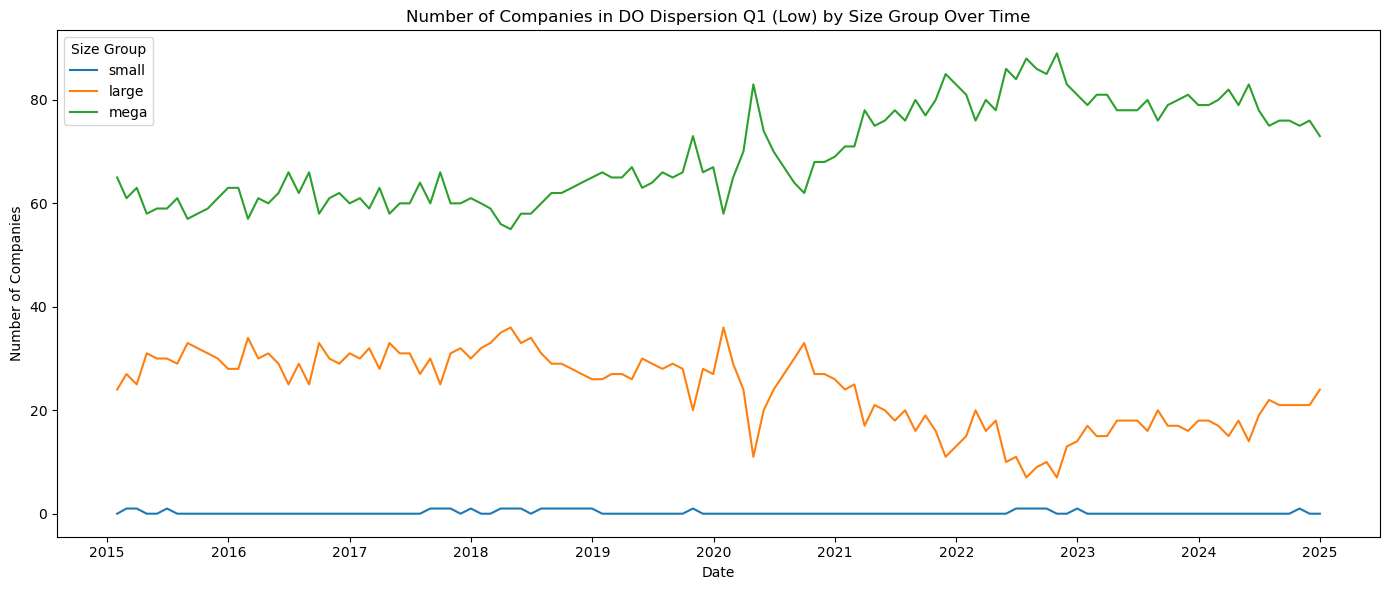

In [82]:
# For each time period, for the 1st quintile, count companies by size_grp
q5_counts = df[df['do_quintile'] == 'Q1 (Low)'].groupby(['eom', 'size_grp'])['id'].nunique().unstack(fill_value=0)

# Plot a line for each size group
fig, ax = plt.subplots(figsize=(14, 6))
for col in q5_counts.columns:
    ax.plot(q5_counts.index, q5_counts[col], label=size_order[int(col)])
ax.set_title('Number of Companies in DO Dispersion Q1 (Low) by Size Group Over Time')
ax.set_ylabel('Number of Companies')
ax.set_xlabel('Date')
ax.legend(title='Size Group')
plt.tight_layout()
plt.show()

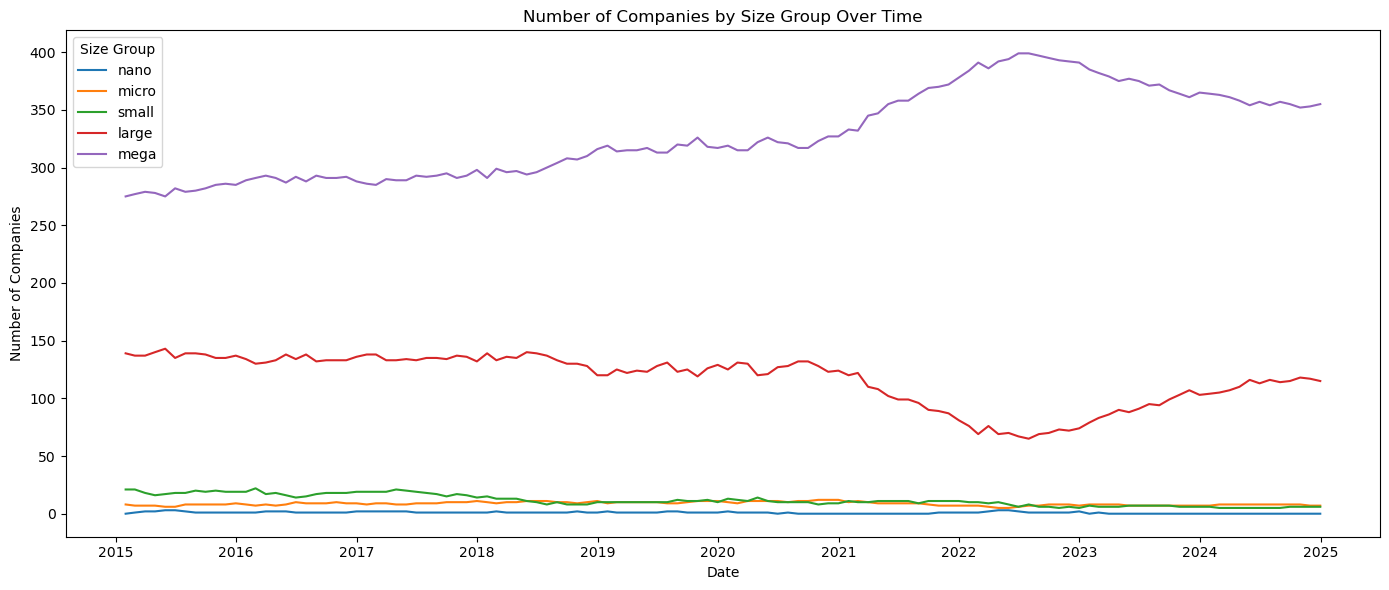

In [83]:
# For each time period, for the 5th quintile, count companies by size_grp
q5_counts = df.groupby(['eom', 'size_grp'])['id'].nunique().unstack(fill_value=0)

# Plot a line for each size group
fig, ax = plt.subplots(figsize=(14, 6))
for col in q5_counts.columns:
    ax.plot(q5_counts.index, q5_counts[col], label=size_order[int(col)])
ax.set_title('Number of Companies by Size Group Over Time')
ax.set_ylabel('Number of Companies')
ax.set_xlabel('Date')
ax.legend(title='Size Group')
plt.tight_layout()
plt.show()

### Earnings Analysis

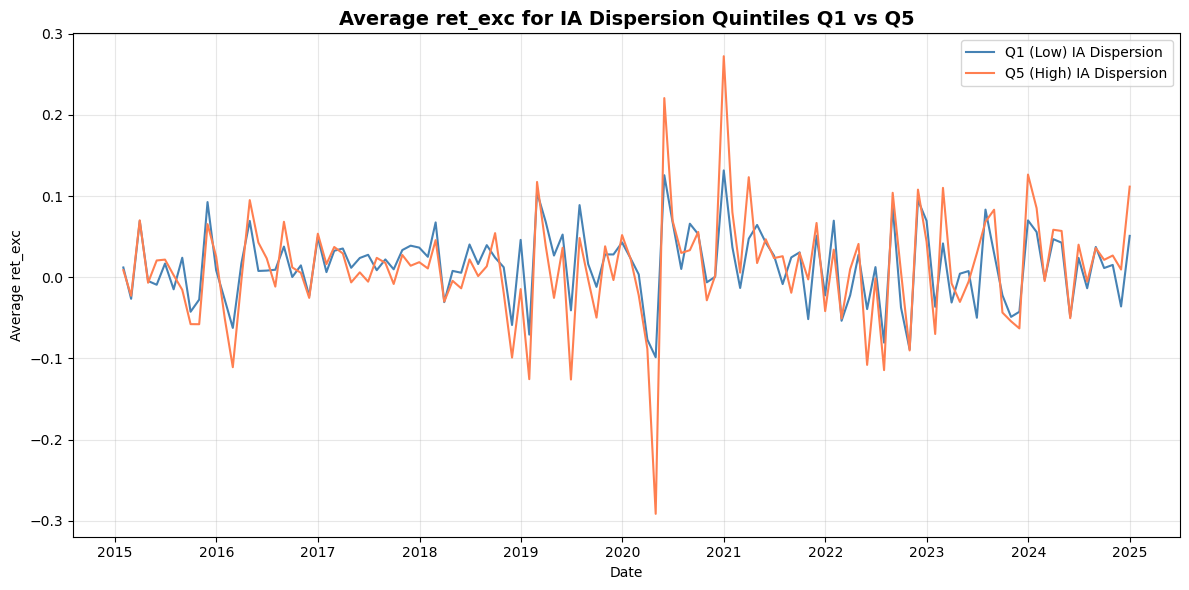

In [85]:
# Plot ret_exc for Q1 (Low) and Q5 (High) IA Dispersion quintiles over time

fig, ax = plt.subplots(figsize=(12, 6))
df_q1 = df[df['ia_quintile'] == 'Q1 (Low)'].groupby('eom')['ret_exc'].mean()
df_q5 = df[df['ia_quintile'] == 'Q5 (High)'].groupby('eom')['ret_exc'].mean()

ax.plot(df_q1.index, df_q1.values, label='Q1 (Low) IA Dispersion', color='steelblue')
ax.plot(df_q5.index, df_q5.values, label='Q5 (High) IA Dispersion', color='coral')
ax.set_title('Average ret_exc for IA Dispersion Quintiles Q1 vs Q5', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Average ret_exc')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [86]:
# Fama-MacBeth test: compare returns between Q1 and Q5 each month, then test if average difference is significant
monthly_diff = df.groupby('eom').apply(
    lambda x: x[x['ia_quintile'] == 'Q5 (High)']['ret_exc'].mean() - 
              x[x['ia_quintile'] == 'Q1 (Low)']['ret_exc'].mean()
).dropna()

# Test if the time-series average difference is significantly different from zero
t_stat = monthly_diff.mean() / (monthly_diff.std(ddof=1) / np.sqrt(len(monthly_diff)))
p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df=len(monthly_diff) - 1))

print(f"Fama-MacBeth test for ret_exc (Q5 High - Q1 Low):")
print(f"  Average monthly difference = {monthly_diff.mean():.4f}")
print(f"  t-statistic = {t_stat:.3f}, p-value = {p_val:.3e}")
print(f"  {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'Not significant'}")

Fama-MacBeth test for ret_exc (Q5 High - Q1 Low):
  Average monthly difference = -0.0028
  t-statistic = -0.824, p-value = 4.117e-01
  Not significant


### Persistence Analysis

In [ ]:
df_sorted = df.sort_values(['id', 'eom'])

# IA Persistence
df_sorted['ia_quintile_next'] = df_sorted.groupby('id')['ia_quintile'].shift(-1)
ia_transition = pd.crosstab(
    df_sorted['ia_quintile'], 
    df_sorted['ia_quintile_next'],
    normalize='index'
)

print("\nIA Dispersion - Transition Matrix (% staying in same quintile next month):")
display(ia_transition.round(3))

# DO Persistence
df_sorted['do_quintile_next'] = df_sorted.groupby('id')['do_quintile'].shift(-1)
do_transition = pd.crosstab(
    df_sorted['do_quintile'], 
    df_sorted['do_quintile_next'],
    normalize='index'
)

print("\nDO Dispersion - Transition Matrix (% staying in same quintile next month):")
display(do_transition.round(3))

# Calculate diagonal (persistence rate)
if len(ia_transition) >= 5:
    ia_persistence = np.diag(ia_transition.values).mean()
    print(f"\nIA Average Persistence Rate: {ia_persistence:.1%}")

if len(do_transition) >= 5:
    do_persistence = np.diag(do_transition.values).mean()
    print(f"DO Average Persistence Rate: {do_persistence:.1%}")


IA Dispersion - Transition Matrix (% staying in same quintile next month):


ia_quintile_next,Q1 (Low),Q2,Q3,Q4,Q5 (High)
ia_quintile,,,,,
Q1 (Low),0.629,0.221,0.092,0.045,0.014
Q2,0.228,0.461,0.215,0.075,0.021
Q3,0.092,0.217,0.440,0.205,0.046
Q4,0.043,0.080,0.211,0.525,0.141
Q5 (High),0.011,0.020,0.043,0.149,0.776



DO Dispersion - Transition Matrix (% staying in same quintile next month):


do_quintile_next,Q1 (Low),Q2,Q3,Q4,Q5 (High)
do_quintile,,,,,
Q1 (Low),0.763,0.179,0.042,0.012,0.004
Q2,0.186,0.584,0.178,0.043,0.009
Q3,0.041,0.192,0.569,0.172,0.026
Q4,0.010,0.037,0.188,0.640,0.125
Q5 (High),0.003,0.008,0.024,0.133,0.833



IA Average Persistence Rate: 56.6%
DO Average Persistence Rate: 67.8%


### Statistical Tests

In [ ]:
# T-tests comparing high vs low quintiles
from scipy.stats import ttest_ind

print("\nT-tests: High Quintile vs Low Quintile")
print("-" * 80)

for char in available_chars:
    # IA test
    ia_high = df[df['ia_quintile'] == 'Q5 (High)'][char].dropna()
    ia_low = df[df['ia_quintile'] == 'Q1 (Low)'][char].dropna()
    
    if len(ia_high) > 0 and len(ia_low) > 0:
        t_stat_ia, p_val_ia = ttest_ind(ia_high, ia_low)
        
        # DO test
        do_high = df[df['do_quintile'] == 'Q5 (High)'][char].dropna()
        do_low = df[df['do_quintile'] == 'Q1 (Low)'][char].dropna()
        
        t_stat_do, p_val_do = ttest_ind(do_high, do_low)
        
        print(f"\n{char}:")
        print(f"  IA: t-stat = {t_stat_ia:7.3f}, p-value = {p_val_ia:.3e} {'***' if p_val_ia < 0.001 else '**' if p_val_ia < 0.01 else '*' if p_val_ia < 0.05 else ''}")
        print(f"  DO: t-stat = {t_stat_do:7.3f}, p-value = {p_val_do:.3e} {'***' if p_val_do < 0.001 else '**' if p_val_do < 0.01 else '*' if p_val_do < 0.05 else ''}")



T-tests: High Quintile vs Low Quintile
--------------------------------------------------------------------------------

size_grp:
  IA: t-stat = -55.961, p-value = 0.000e+00 ***
  DO: t-stat = -59.680, p-value = 0.000e+00 ***


In [ ]:
summary_findings = {
    'Metric': [
        'High-to-Low Ratio (IA)',
        'High-to-Low Ratio (DO)',
        'Persistence Rate (IA)',
        'Persistence Rate (DO)',
        'Avg Size (High IA)',
        'Avg Size (Low IA)',
        'Avg Size (High DO)',
        'Avg Size (Low DO)'
    ],
    'Value': [
        f"{ia_ratio:.2f}x",
        f"{do_ratio:.2f}x",
        f"{ia_persistence:.1%}" if 'ia_persistence' in locals() else 'N/A',
        f"{do_persistence:.1%}" if 'do_persistence' in locals() else 'N/A',
        f"{ia_char_summary.loc['Q5 (High)', 'mvel1']:.2f}" if 'mvel1' in ia_char_summary.columns else 'N/A',
        f"{ia_char_summary.loc['Q1 (Low)', 'mvel1']:.2f}" if 'mvel1' in ia_char_summary.columns else 'N/A',
        f"{do_char_summary.loc['Q5 (High)', 'mvel1']:.2f}" if 'mvel1' in do_char_summary.columns else 'N/A',
        f"{do_char_summary.loc['Q1 (Low)', 'mvel1']:.2f}" if 'mvel1' in do_char_summary.columns else 'N/A'
    ]
}
# Fix the column reference from 'mvel1' to 'size_grp'
summary_findings['Value'][4] = f"{ia_char_summary.loc['Q5 (High)', 'size_grp']:.2f}" if 'size_grp' in ia_char_summary.columns else 'N/A'
summary_findings['Value'][5] = f"{ia_char_summary.loc['Q1 (Low)', 'size_grp']:.2f}" if 'size_grp' in ia_char_summary.columns else 'N/A'
summary_findings['Value'][6] = f"{do_char_summary.loc['Q5 (High)', 'size_grp']:.2f}" if 'size_grp' in do_char_summary.columns else 'N/A'
summary_findings['Value'][7] = f"{do_char_summary.loc['Q1 (Low)', 'size_grp']:.2f}" if 'size_grp' in do_char_summary.columns else 'N/A'
summary_table = pd.DataFrame(summary_findings)
display(summary_table)


,Metric,Value
0,High-to-Low Ratio (IA),3.18x
1,High-to-Low Ratio (DO),10.87x
2,Persistence Rate (IA),56.6%
3,Persistence Rate (DO),67.8%
4,Avg Size (High IA),3.22
5,Avg Size (Low IA),3.79
6,Avg Size (High DO),3.22
7,Avg Size (Low DO),3.82


Here we can see that the dispersion in DO is significantly higher than the dispersion of IA, showing that the difference of Opinion can set investors much further apart than Information Assymmetrie. Further difference of opinions seem to be significantly more persistent as well, showing that when dealing with own beliefs it is more unlikely to change them. It is also notable that the persistence shows a diagonal trend in the transistion matrix (it is most likely to stay in the same quantile). The highest persistence values are evident in the two extrem quantiles, meaning that once the dispersion reaches an extreme it tends to stay that way.
Last but not least, we could identify a significant difference in size of stocks with higher dispersion. In order to address this finding further we want to see how this compares with the Small-Minus-Big Parameter of Fama French. 

Return factors constructed for 120 periods

Summary statistics:
       ia_ret_factor  do_ret_factor         smb
count     120.000000     120.000000  120.000000
mean        0.004860       0.002918   -0.043500
std         0.047751       0.050835    0.593886
min        -0.278303      -0.271765   -2.050000
25%        -0.015044      -0.016528   -0.345000
50%         0.005865       0.003107   -0.045000
75%         0.023727       0.021490    0.397500
max         0.197358       0.208413    1.530000

Correlation - IA Return Factor & SMB: -0.3065
Correlation - DO Return Factor & SMB: -0.2866
Correlation - IA & DO Return Factors: 0.9753

REGRESSION RESULTS

IA RETURN FACTOR ~ SMB:
                            OLS Regression Results                            
Dep. Variable:          ia_ret_factor   R-squared:                       0.094
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     12.23
Date:

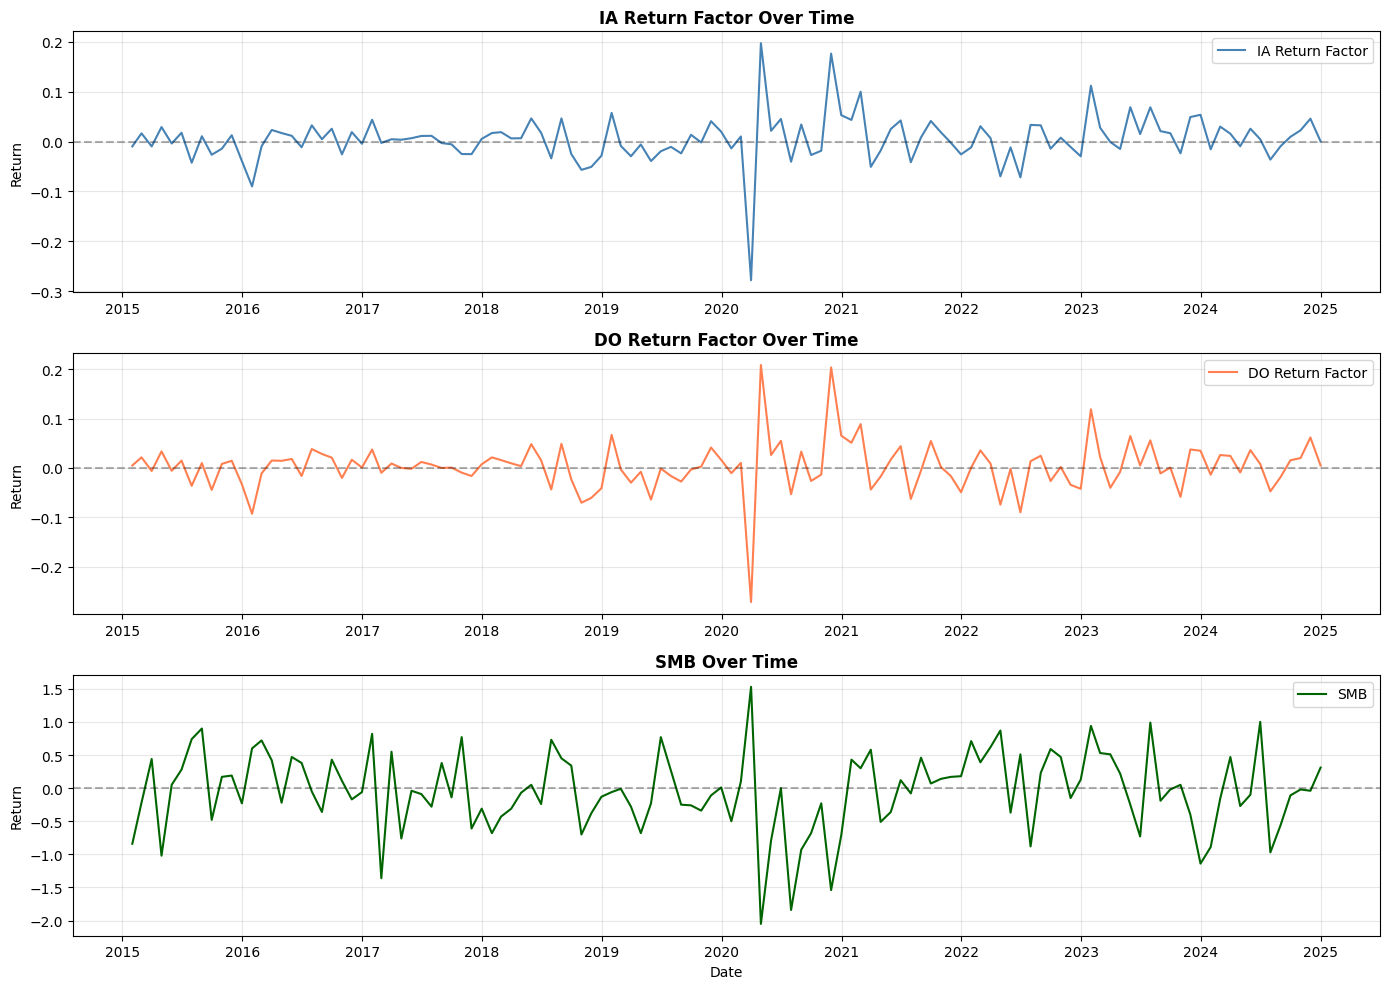

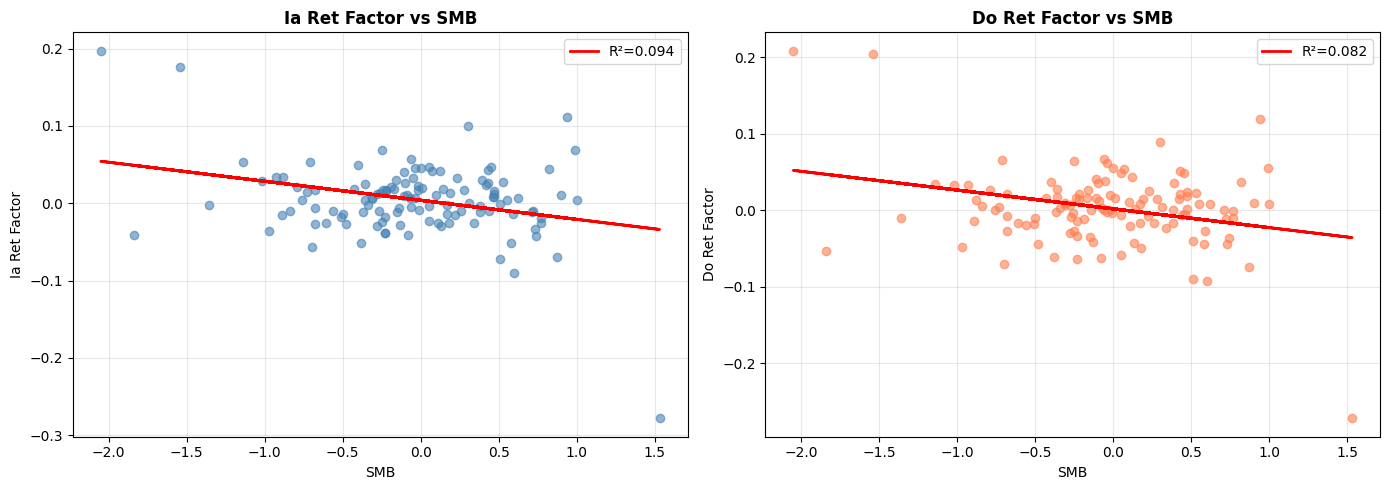

In [ ]:
# Identify column names
size_col = 'size_grp' if 'size_grp' in df.columns else 'mvel1'
ret_col = 'ret_excess' if 'ret_excess' in df.columns else 'ret'
date_col = 'eom'
ia_quintile_col = 'ia_quintile' if 'ia_quintile' in df.columns else 'ia_q'
do_quintile_col = 'do_quintile' if 'do_quintile' in df.columns else 'do_q'


def make_long_short_return_factor(df, quintile_col, ret_col, date_col='eom'):
    """Construct long-short return factor: High quintile - Low quintile"""
    unique_vals = df[quintile_col].dropna().unique()
    high_label = 'Q5 (High)' if any('High' in str(v) for v in unique_vals) else 5
    low_label = 'Q1 (Low)' if any('Low' in str(v) for v in unique_vals) else 1

    high_ret = df[df[quintile_col] == high_label].groupby(date_col)[ret_col].mean()
    low_ret = df[df[quintile_col] == low_label].groupby(date_col)[ret_col].mean()

    factor = high_ret - low_ret
    factor.name = f"{quintile_col}_ls_factor"
    return factor


# Construct IA and DO return factors
ia_ret_factor = make_long_short_return_factor(df, ia_quintile_col, ret_col, date_col)
do_ret_factor = make_long_short_return_factor(df, do_quintile_col, ret_col, date_col)

factors_df = pd.DataFrame({
    'ia_ret_factor': ia_ret_factor,
    'do_ret_factor': do_ret_factor
}).join(df.groupby(date_col)['smb'].first()).dropna()

print(f"Return factors constructed for {len(factors_df)} periods")
print("\nSummary statistics:")
print(factors_df.describe())


# Correlations
corr_ia_smb = factors_df['ia_ret_factor'].corr(factors_df['smb'])
corr_do_smb = factors_df['do_ret_factor'].corr(factors_df['smb'])
corr_ia_do = factors_df['ia_ret_factor'].corr(factors_df['do_ret_factor'])

print(f"\nCorrelation - IA Return Factor & SMB: {corr_ia_smb:.4f}")
print(f"Correlation - DO Return Factor & SMB: {corr_do_smb:.4f}")
print(f"Correlation - IA & DO Return Factors: {corr_ia_do:.4f}")


# Regressions: Factor ~ SMB
import statsmodels.api as sm

reg_df = factors_df[['ia_ret_factor', 'do_ret_factor', 'smb']].dropna()
X = sm.add_constant(reg_df['smb'])

model_ia = sm.OLS(reg_df['ia_ret_factor'], X).fit()
model_do = sm.OLS(reg_df['do_ret_factor'], X).fit()

print("\n" + "="*80)
print("REGRESSION RESULTS")
print("="*80)
print("\nIA RETURN FACTOR ~ SMB:")
print(model_ia.summary())
print("\nDO RETURN FACTOR ~ SMB:")
print(model_do.summary())


# Summary comparison table
summary_comparison = pd.DataFrame({
    'Factor': ['IA Return Factor', 'DO Return Factor'],
    'Mean': [reg_df['ia_ret_factor'].mean(), reg_df['do_ret_factor'].mean()],
    'Std Dev': [reg_df['ia_ret_factor'].std(), reg_df['do_ret_factor'].std()],
    'Corr with SMB': [corr_ia_smb, corr_do_smb],
    'R² vs SMB': [model_ia.rsquared, model_do.rsquared],
    'Beta on SMB': [model_ia.params['smb'], model_do.params['smb']],
    'p-value': [model_ia.pvalues['smb'], model_do.pvalues['smb']]
})
print("\n" + "="*80)
print("SUMMARY COMPARISON")
print("="*80)
print(summary_comparison.to_string(index=False))


# Visualizations
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for ax, col, label, color in zip(
    axes,
    ['ia_ret_factor', 'do_ret_factor', 'smb'],
    ['IA Return Factor', 'DO Return Factor', 'SMB'],
    ['steelblue', 'coral', 'darkgreen']
):
    ax.plot(factors_df.index, factors_df[col], label=label, color=color, linewidth=1.5)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    ax.set_title(f'{label} Over Time', fontsize=12, fontweight='bold')
    ax.set_ylabel('Return', fontsize=10)
    ax.legend()
    ax.grid(True, alpha=0.3)
axes[2].set_xlabel('Date', fontsize=10)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, factor, model, color in zip(
    axes,
    ['ia_ret_factor', 'do_ret_factor'],
    [model_ia, model_do],
    ['steelblue', 'coral']
):
    ax.scatter(reg_df['smb'], reg_df[factor], alpha=0.6, color=color)
    ax.plot(reg_df['smb'], model.fittedvalues, color='red', linewidth=2,
            label=f'R²={model.rsquared:.3f}')
    ax.set_xlabel('SMB', fontsize=10)
    ax.set_ylabel(factor.replace('_', ' ').title(), fontsize=10)
    ax.set_title(f'{factor.replace("_", " ").title()} vs SMB', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


We can see that the differences between both the IA and DO with the SMB seem to be significant. Even though there is a difference in the size of the companies, our IA and DO scores seem to capture futher differences and do not resemble the Fama French's SMB Factor.

## Variance Decomposition

In [19]:
# df = pd.read_csv("data_dispersions.csv")
# # Convert eom to datetime
# df['eom'] = pd.to_datetime(df['eom'])

COMPREHENSIVE VAR MODEL - ALL VARIABLES

Variables included: ['ret_exc_lead1m', 'ia_mean', 'ia_dispersion', 'do_mean', 'do_dispersion']
Sample size: 120 months
Date range: 2015-01-31 to 2024-12-31

Selected VAR lags (AIC): 1

VAR(1) Model Summary:
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 01, Dec, 2025
Time:                     14:20:35
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                   -8.82684
Nobs:                     119.000    HQIC:                  -9.24296
Log likelihood:          -247.385    FPE:                7.28556e-05
AIC:                     -9.52746    Det(Omega_mle):     5.69702e-05
--------------------------------------------------------------------
Results for equation ret_exc_lead1m
                       coefficient       std. error           t-stat            prob
------------------------------------------

,Shock: ret_exc_lead1m,Shock: ia_mean,Shock: ia_dispersion,Shock: do_mean,Shock: do_dispersion
Horizon (m),,,,,
1,1.000,0.000,0.000,0.000,0.000
2,0.000,1.000,0.000,0.000,0.000
3,0.003,0.535,0.462,0.000,0.000
4,0.001,0.390,0.084,0.524,0.000
5,0.008,0.324,0.110,0.419,0.139


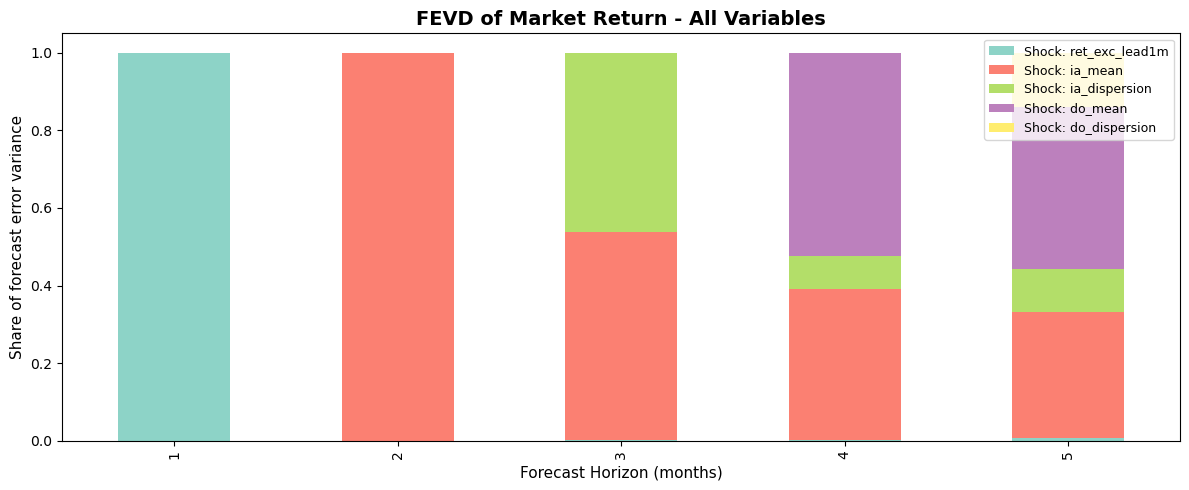


2. FEVD of ia_mean:


,Shock: ret_exc_lead1m,Shock: ia_mean,Shock: ia_dispersion,Shock: do_mean,Shock: do_dispersion
Horizon (m),,,,,
1,0.997,0.001,0.000,0.002,0.00
2,0.001,0.999,0.000,0.001,0.00
3,0.007,0.520,0.472,0.000,0.00
4,0.002,0.388,0.074,0.535,0.00
5,0.023,0.320,0.100,0.416,0.14


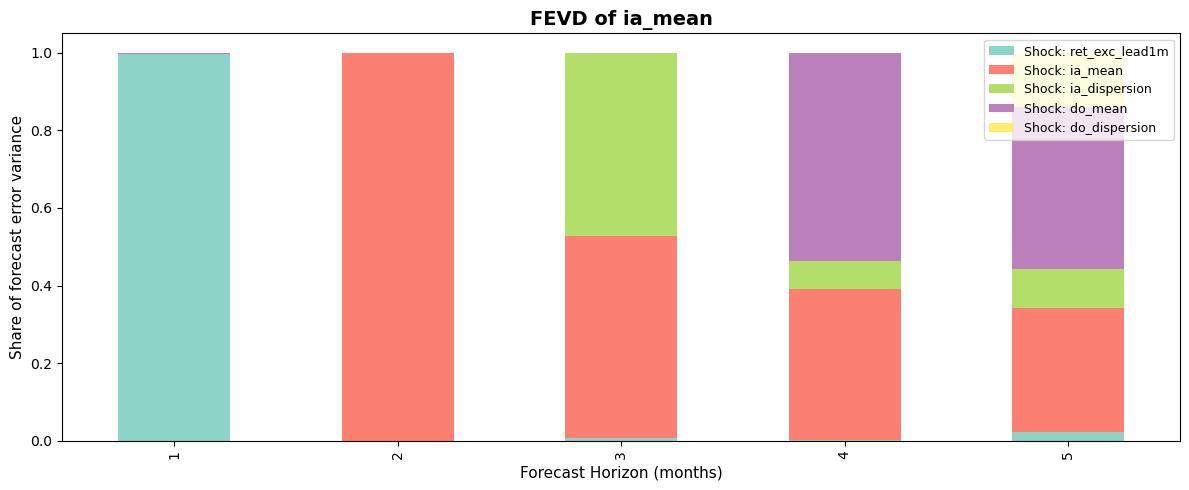


3. FEVD of ia_dispersion:


,Shock: ret_exc_lead1m,Shock: ia_mean,Shock: ia_dispersion,Shock: do_mean,Shock: do_dispersion
Horizon (m),,,,,
1,0.995,0.001,0.000,0.003,0.000
2,0.001,0.997,0.000,0.002,0.000
3,0.008,0.509,0.483,0.000,0.000
4,0.002,0.385,0.066,0.545,0.001
5,0.026,0.320,0.092,0.419,0.142


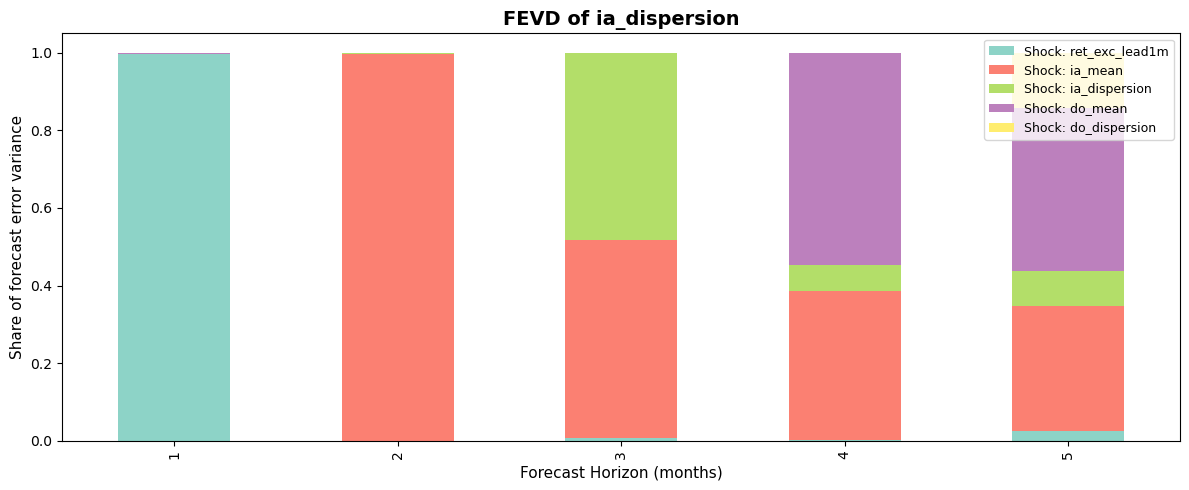


4. FEVD of do_mean:


,Shock: ret_exc_lead1m,Shock: ia_mean,Shock: ia_dispersion,Shock: do_mean,Shock: do_dispersion
Horizon (m),,,,,
1,0.994,0.001,0.000,0.004,0.000
2,0.001,0.995,0.001,0.004,0.000
3,0.008,0.498,0.493,0.000,0.000
4,0.002,0.383,0.060,0.554,0.002
5,0.027,0.321,0.085,0.422,0.144


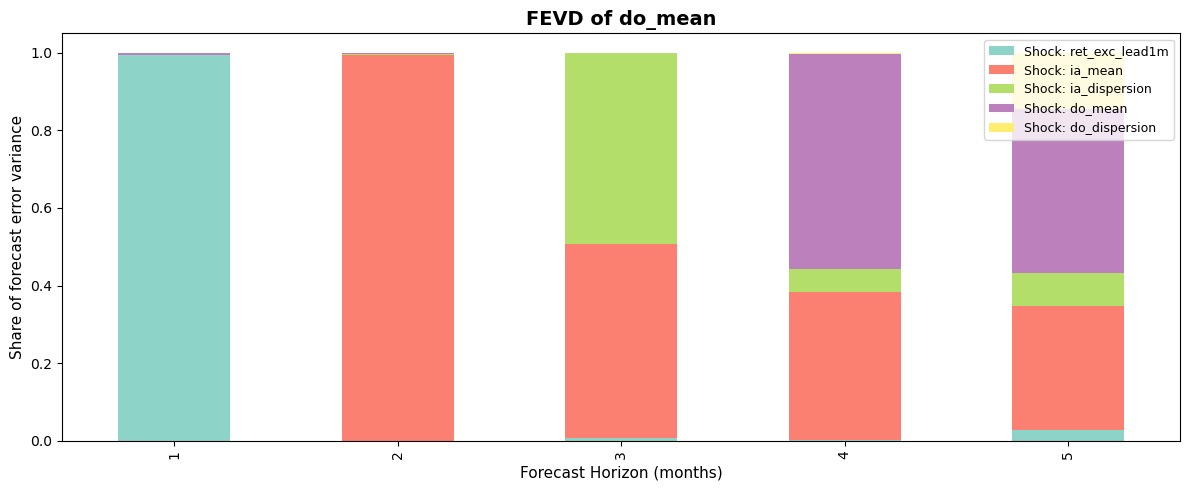


5. FEVD of do_dispersion:


,Shock: ret_exc_lead1m,Shock: ia_mean,Shock: ia_dispersion,Shock: do_mean,Shock: do_dispersion
Horizon (m),,,,,
1,0.993,0.001,0.000,0.005,0.000
2,0.001,0.992,0.001,0.006,0.000
3,0.008,0.488,0.502,0.001,0.001
4,0.001,0.380,0.055,0.560,0.004
5,0.028,0.321,0.079,0.425,0.146


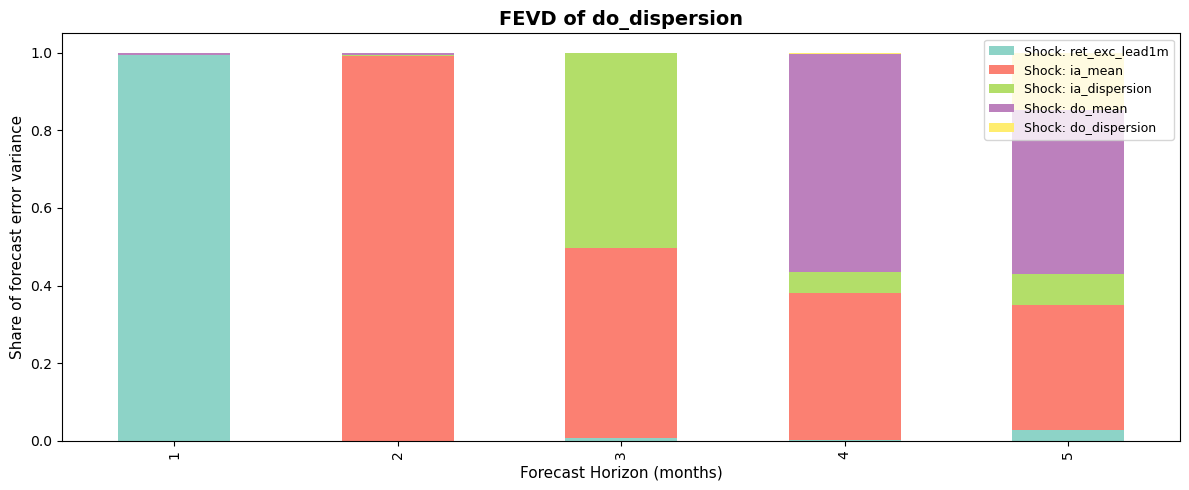


SUMMARY: VARIANCE DECOMPOSITION AT KEY HORIZONS

--- Horizon: 1 month(s) ---


,Shock: ret_exc_lead1m,Shock: ia_mean,Shock: ia_dispersion,Shock: do_mean,Shock: do_dispersion
ret_exc_lead1m,1.000,0.000,0.0,0.000,0.0
ia_mean,0.997,0.001,0.0,0.002,0.0
ia_dispersion,0.995,0.001,0.0,0.003,0.0
do_mean,0.994,0.001,0.0,0.004,0.0
do_dispersion,0.993,0.001,0.0,0.005,0.0



--- Horizon: 3 month(s) ---


,Shock: ret_exc_lead1m,Shock: ia_mean,Shock: ia_dispersion,Shock: do_mean,Shock: do_dispersion
ret_exc_lead1m,0.003,0.535,0.462,0.000,0.000
ia_mean,0.007,0.520,0.472,0.000,0.000
ia_dispersion,0.008,0.509,0.483,0.000,0.000
do_mean,0.008,0.498,0.493,0.000,0.000
do_dispersion,0.008,0.488,0.502,0.001,0.001


In [20]:
# Comprehensive VAR Analysis with All Variables

# Prepare market-level aggregates including both IA and DO measures
market = df.groupby('eom')[['ret_exc_lead1m', 'ia_mean', 'ia_dispersion', 'do_mean', 'do_dispersion']].mean().dropna()

# Standardize all variables
m_std = (market - market.mean()) / market.std()

print("=" * 80)
print("COMPREHENSIVE VAR MODEL - ALL VARIABLES")
print("=" * 80)
print(f"\nVariables included: {list(m_std.columns)}")
print(f"Sample size: {len(m_std)} months")
print(f"Date range: {pd.to_datetime(market.index.min()).strftime('%Y-%m-%d')} to {pd.to_datetime(market.index.max()).strftime('%Y-%m-%d')}")

# Fit VAR model
model = VAR(m_std)
sel = model.select_order(maxlags=6)
p = sel.aic if getattr(sel, 'aic', None) is not None else 1
print(f'\nSelected VAR lags (AIC): {p}')

var_res = model.fit(p)
print(f"\nVAR({p}) Model Summary:")
print(var_res.summary())

# Compute Forecast Error Variance Decomposition (FEVD)
fevd = var_res.fevd(12)
h = fevd.decomp.shape[0]
labels = list(m_std.columns)

print("\n" + "=" * 80)
print("FORECAST ERROR VARIANCE DECOMPOSITION (FEVD)")
print("=" * 80)

# 1. FEVD of Market Return
ret_idx = m_std.columns.get_loc('ret_exc_lead1m')
fevd_ret = pd.DataFrame(
    fevd.decomp[:, ret_idx, :], 
    columns=[f'Shock: {c}' for c in labels], 
    index=pd.Index(range(1, h + 1), name='Horizon (m)')
)
print('\n1. FEVD of Market Return (ret_exc_lead1m):')
display(fevd_ret.round(3))

fig, ax = plt.subplots(figsize=(12, 5))
fevd_ret.plot(kind='bar', stacked=True, ax=ax, colormap='Set3')
ax.set_title('FEVD of Market Return - All Variables', fontsize=14, fontweight='bold')
ax.set_ylabel('Share of forecast error variance', fontsize=11)
ax.set_xlabel('Forecast Horizon (months)', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

# 2. FEVD for each variable
for var_name in ['ia_mean', 'ia_dispersion', 'do_mean', 'do_dispersion']:
    vidx = m_std.columns.get_loc(var_name)
    fevd_tbl = pd.DataFrame(
        fevd.decomp[:, vidx, :], 
        columns=[f'Shock: {c}' for c in labels], 
        index=pd.Index(range(1, h + 1), name='Horizon (m)')
    )
    
    print(f'\n{["2.", "3.", "4.", "5."][["ia_mean", "ia_dispersion", "do_mean", "do_dispersion"].index(var_name)]} FEVD of {var_name}:')
    display(fevd_tbl.round(3))
    
    fig, ax = plt.subplots(figsize=(12, 5))
    fevd_tbl.plot(kind='bar', stacked=True, ax=ax, colormap='Set3')
    ax.set_title(f'FEVD of {var_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Share of forecast error variance', fontsize=11)
    ax.set_xlabel('Forecast Horizon (months)', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()

# Summary statistics at key horizons
print("\n" + "=" * 80)
print("SUMMARY: VARIANCE DECOMPOSITION AT KEY HORIZONS")
print("=" * 80)

for horizon in [1, 3, 6, 12]:
    if horizon <= h:
        print(f"\n--- Horizon: {horizon} month(s) ---")
        horizon_data = {}
        
        for i, var_name in enumerate(labels):
            vidx = m_std.columns.get_loc(var_name)
            decomp = fevd.decomp[horizon-1, vidx, :]
            horizon_data[var_name] = decomp
        
        horizon_df = pd.DataFrame(horizon_data, index=[f'Shock: {c}' for c in labels]).T
        display(horizon_df.round(3))

### Interpretation: Comprehensive VAR Model

The 5-variable VAR model includes market returns, IA mean, IA dispersion, DO mean, and DO dispersion, providing a complete picture of the dynamic interactions between disagreement measures and returns.

**Key Findings:**

1. **Market Return Dynamics**: The decomposition reveals how much of the forecast error variance in market returns is explained by shocks to each of the four disagreement/prediction measures versus own innovations.

2. **IA vs DO Comparison**: By including both IA and DO measures simultaneously, we can directly assess their relative importance and whether they contain independent information or largely overlap.

3. **Mean vs Dispersion**: The model distinguishes between the level of predicted returns (mean) and the degree of disagreement (dispersion), showing their distinct roles in explaining return dynamics.

4. **Short vs Long Horizons**: 
   - At horizon 1, variables typically show strong own-shock dominance
   - By horizons 3-6, cross-variable effects become more prominent
   - At 12 months, the decomposition stabilizes to show long-run relationships

5. **Economic Interpretation**: High variance shares from dispersion shocks to returns suggest that investor disagreement contains information about future return volatility and risk premia. The relative contributions of IA vs DO measures indicate which type of information asymmetry (heterogeneous information sets vs model uncertainty) is more important for asset pricing.

### Focused VAR Analysis: Information Asymmetry (IA) Measures

VAR MODEL - INFORMATION ASYMMETRY (IA) MEASURES

Variables: ['ret_exc_lead1m', 'ia_mean', 'ia_dispersion']
Sample size: 120 months
Date range: 2015-01-31 to 2024-12-31

Selected VAR lags (AIC): 1

VAR(1) Model Summary:
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 01, Dec, 2025
Time:                     14:20:36
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -3.46230
Nobs:                     119.000    HQIC:                  -3.62875
Log likelihood:          -271.880    FPE:                  0.0236955
AIC:                     -3.74255    Det(Omega_mle):       0.0214581
--------------------------------------------------------------------
Results for equation ret_exc_lead1m
                       coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------

,Shock: ret_exc_lead1m,Shock: ia_mean,Shock: ia_dispersion
Horizon (m),,,
1,1.000,0.000,0.000
2,0.000,1.000,0.000
3,0.003,0.528,0.469


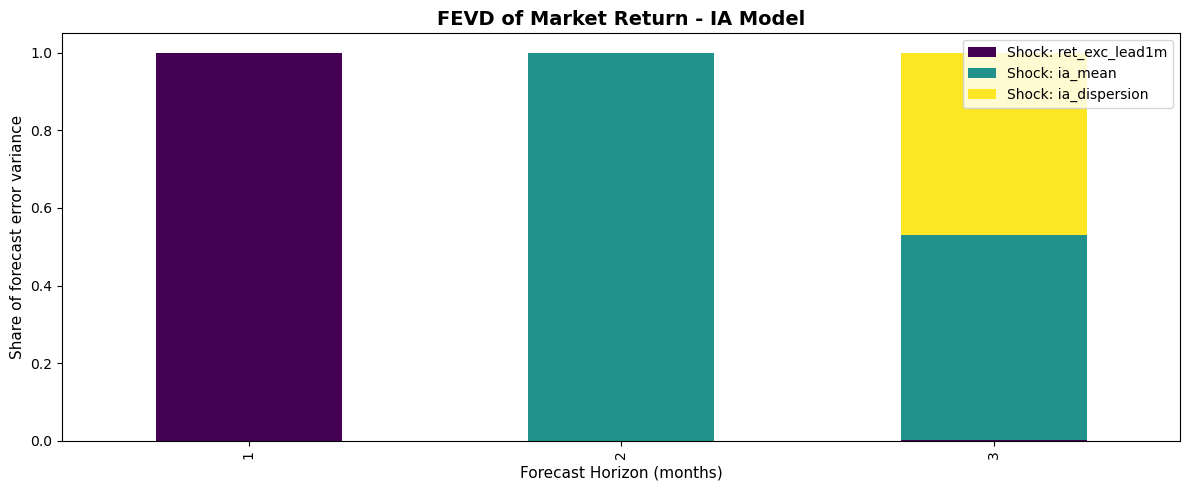


FEVD of ia_mean:


,Shock: ret_exc_lead1m,Shock: ia_mean,Shock: ia_dispersion
Horizon (m),,,
1,0.999,0.001,0.000
2,0.001,0.999,0.000
3,0.008,0.509,0.483


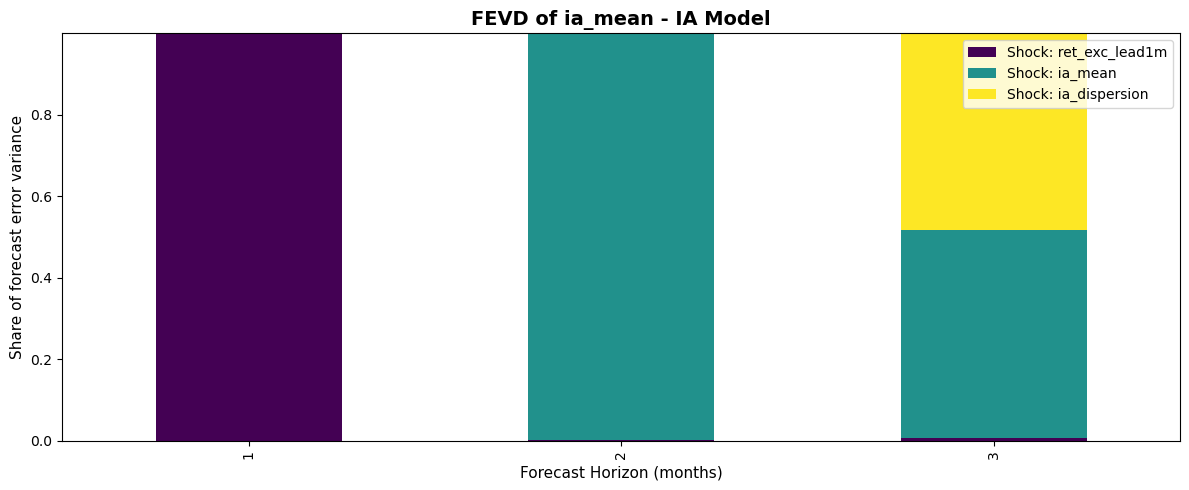


FEVD of ia_dispersion:


,Shock: ret_exc_lead1m,Shock: ia_mean,Shock: ia_dispersion
Horizon (m),,,
1,0.999,0.001,0.000
2,0.001,0.998,0.001
3,0.008,0.494,0.498


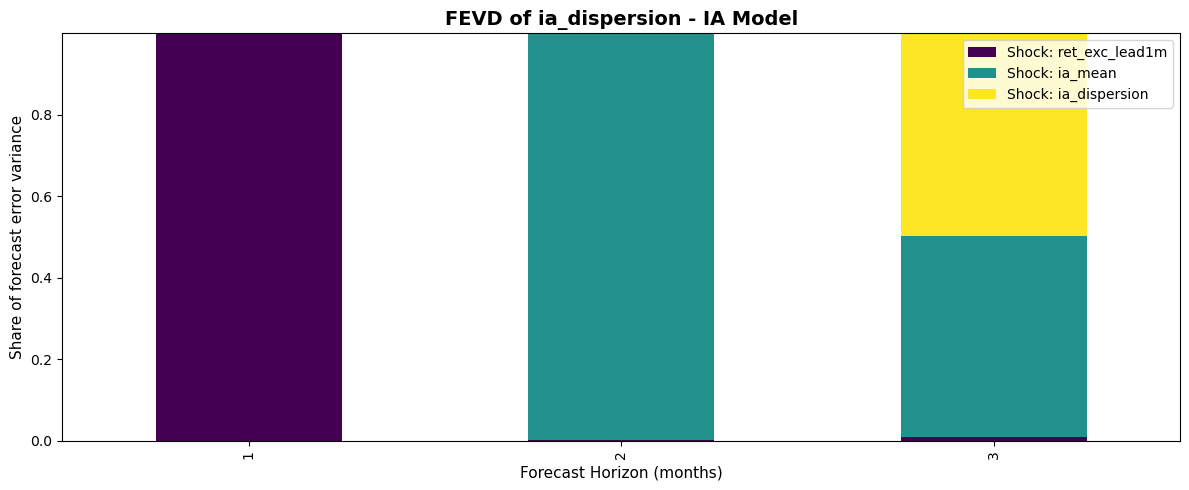


IA MODEL - KEY HORIZONS SUMMARY

--- Horizon: 1 month(s) ---


,Shock: ret_exc_lead1m,Shock: ia_mean,Shock: ia_dispersion
ret_exc_lead1m,1.000,0.000,0.0
ia_mean,0.999,0.001,0.0
ia_dispersion,0.999,0.001,0.0



--- Horizon: 3 month(s) ---


,Shock: ret_exc_lead1m,Shock: ia_mean,Shock: ia_dispersion
ret_exc_lead1m,0.003,0.528,0.469
ia_mean,0.008,0.509,0.483
ia_dispersion,0.008,0.494,0.498



GRANGER CAUSALITY TESTS - IA MODEL

ia_mean → ret_exc_lead1m:
  F-statistic: 0.3134
  p-value: 0.5760
  Significant: No

ia_dispersion → ret_exc_lead1m:
  F-statistic: 0.0001
  p-value: 0.9926
  Significant: No

ret_exc_lead1m → ia_mean:
  F-statistic: 0.0578
  p-value: 0.8102
  Significant: No

ia_dispersion → ia_mean:
  F-statistic: 0.5434
  p-value: 0.4615
  Significant: No

ret_exc_lead1m → ia_dispersion:
  F-statistic: 0.2920
  p-value: 0.5893
  Significant: No

ia_mean → ia_dispersion:
  F-statistic: 1.4040
  p-value: 0.2369
  Significant: No


In [21]:
# VAR Analysis: IA Measures (ret_exc_lead1m, ia_mean, ia_dispersion)

print("=" * 80)
print("VAR MODEL - INFORMATION ASYMMETRY (IA) MEASURES")
print("=" * 80)

# Prepare IA-focused dataset
market_ia = df.groupby('eom')[['ret_exc_lead1m', 'ia_mean', 'ia_dispersion']].mean().dropna()
m_ia_std = (market_ia - market_ia.mean()) / market_ia.std()

print(f"\nVariables: {list(m_ia_std.columns)}")
print(f"Sample size: {len(m_ia_std)} months")
print(f"Date range: {pd.to_datetime(market_ia.index.min()).strftime('%Y-%m-%d')} to {pd.to_datetime(market_ia.index.max()).strftime('%Y-%m-%d')}")

# Fit VAR model for IA
model_ia = VAR(m_ia_std)
sel_ia = model_ia.select_order(maxlags=6)
p_ia = sel_ia.aic if getattr(sel_ia, 'aic', None) is not None else 1
print(f'\nSelected VAR lags (AIC): {p_ia}')

var_res_ia = model_ia.fit(p_ia)
print(f"\nVAR({p_ia}) Model Summary:")
print(var_res_ia.summary())

# FEVD for IA model
fevd_ia = var_res_ia.fevd(12)
h_ia = fevd_ia.decomp.shape[0]
labels_ia = list(m_ia_std.columns)

print("\n" + "=" * 80)
print("FEVD - IA MODEL")
print("=" * 80)

# Market return decomposition
ret_idx_ia = m_ia_std.columns.get_loc('ret_exc_lead1m')
fevd_ret_ia = pd.DataFrame(
    fevd_ia.decomp[:, ret_idx_ia, :], 
    columns=[f'Shock: {c}' for c in labels_ia], 
    index=pd.Index(range(1, h_ia + 1), name='Horizon (m)')
)
print('\nFEVD of Market Return (IA model):')
display(fevd_ret_ia.round(3))

fig, ax = plt.subplots(figsize=(12, 5))
fevd_ret_ia.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
ax.set_title('FEVD of Market Return - IA Model', fontsize=14, fontweight='bold')
ax.set_ylabel('Share of forecast error variance', fontsize=11)
ax.set_xlabel('Forecast Horizon (months)', fontsize=11)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

# Decomposition for ia_mean and ia_dispersion
for var_name in ['ia_mean', 'ia_dispersion']:
    vidx_ia = m_ia_std.columns.get_loc(var_name)
    fevd_tbl_ia = pd.DataFrame(
        fevd_ia.decomp[:, vidx_ia, :], 
        columns=[f'Shock: {c}' for c in labels_ia], 
        index=pd.Index(range(1, h_ia + 1), name='Horizon (m)')
    )
    
    print(f'\nFEVD of {var_name}:')
    display(fevd_tbl_ia.round(3))
    
    fig, ax = plt.subplots(figsize=(12, 5))
    fevd_tbl_ia.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
    ax.set_title(f'FEVD of {var_name} - IA Model', fontsize=14, fontweight='bold')
    ax.set_ylabel('Share of forecast error variance', fontsize=11)
    ax.set_xlabel('Forecast Horizon (months)', fontsize=11)
    ax.legend(loc='upper right', fontsize=10)
    plt.tight_layout()
    plt.show()

# Summary at key horizons
print("\n" + "=" * 80)
print("IA MODEL - KEY HORIZONS SUMMARY")
print("=" * 80)

for horizon in [1, 3, 6, 12]:
    if horizon <= h_ia:
        print(f"\n--- Horizon: {horizon} month(s) ---")
        horizon_data_ia = {}
        
        for i, var_name in enumerate(labels_ia):
            vidx_ia = m_ia_std.columns.get_loc(var_name)
            decomp_ia = fevd_ia.decomp[horizon-1, vidx_ia, :]
            horizon_data_ia[var_name] = decomp_ia
        
        horizon_df_ia = pd.DataFrame(horizon_data_ia, index=[f'Shock: {c}' for c in labels_ia]).T
        display(horizon_df_ia.round(3))

# Granger causality tests
print("\n" + "=" * 80)
print("GRANGER CAUSALITY TESTS - IA MODEL")
print("=" * 80)

for caused_var in labels_ia:
    for causing_var in labels_ia:
        if caused_var != causing_var:
            test_result = var_res_ia.test_causality(caused_var, causing_var, kind='f')
            print(f"\n{causing_var} → {caused_var}:")
            print(f"  F-statistic: {test_result.test_statistic:.4f}")
            print(f"  p-value: {test_result.pvalue:.4f}")
            print(f"  Significant: {'Yes' if test_result.pvalue < 0.05 else 'No'}")

### Focused VAR Analysis: Difference of Opinion (DO) Measures

VAR MODEL - DIFFERENCE OF OPINION (DO) MEASURES

Variables: ['ret_exc_lead1m', 'do_mean', 'do_dispersion']
Sample size: 120 months
Date range: 2015-01-31 to 2024-12-31

Selected VAR lags (AIC): 2

VAR(2) Model Summary:
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 01, Dec, 2025
Time:                     14:20:37
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -4.69615
Nobs:                     118.000    HQIC:                  -4.98903
Log likelihood:          -175.139    FPE:                 0.00557860
AIC:                     -5.18924    Det(Omega_mle):      0.00469290
--------------------------------------------------------------------
Results for equation ret_exc_lead1m
                       coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------

,Shock: ret_exc_lead1m,Shock: do_mean,Shock: do_dispersion
Horizon (m),,,
1,1.000,0.000,0.000
2,0.002,0.998,0.000
3,0.005,0.864,0.131


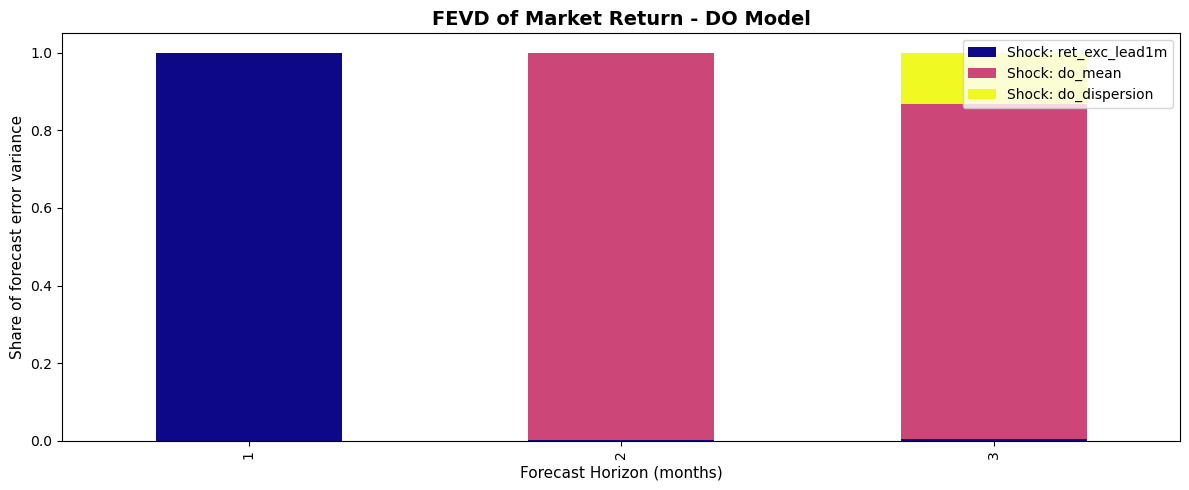


FEVD of do_mean:


,Shock: ret_exc_lead1m,Shock: do_mean,Shock: do_dispersion
Horizon (m),,,
1,0.985,0.009,0.005
2,0.002,0.997,0.002
3,0.016,0.889,0.095


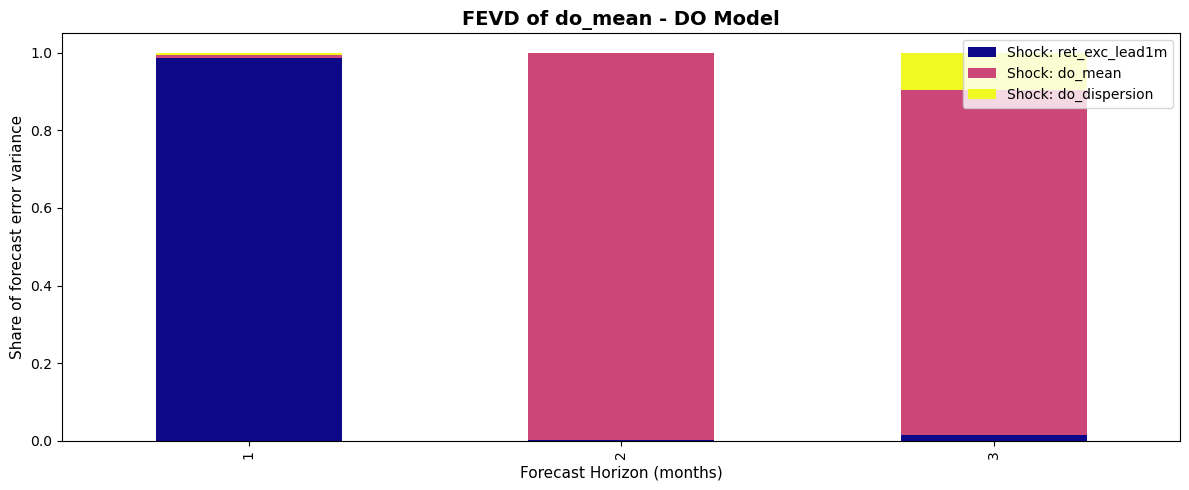


FEVD of do_dispersion:


,Shock: ret_exc_lead1m,Shock: do_mean,Shock: do_dispersion
Horizon (m),,,
1,0.984,0.010,0.006
2,0.005,0.993,0.002
3,0.012,0.898,0.091


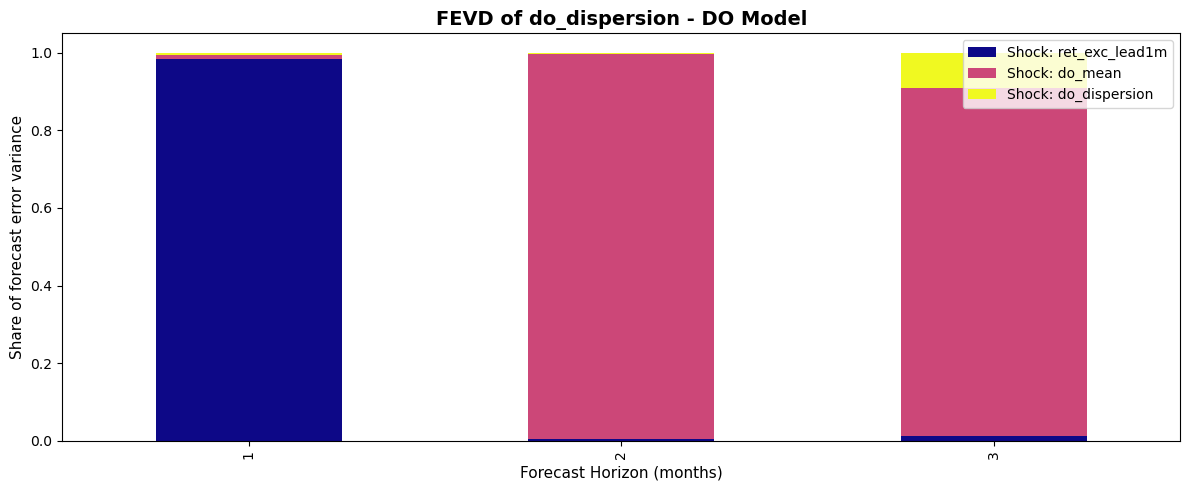


DO MODEL - KEY HORIZONS SUMMARY

--- Horizon: 1 month(s) ---


,Shock: ret_exc_lead1m,Shock: do_mean,Shock: do_dispersion
ret_exc_lead1m,1.000,0.000,0.000
do_mean,0.985,0.009,0.005
do_dispersion,0.984,0.010,0.006



--- Horizon: 3 month(s) ---


,Shock: ret_exc_lead1m,Shock: do_mean,Shock: do_dispersion
ret_exc_lead1m,0.005,0.864,0.131
do_mean,0.016,0.889,0.095
do_dispersion,0.012,0.898,0.091



GRANGER CAUSALITY TESTS - DO MODEL

do_mean → ret_exc_lead1m:
  F-statistic: 1.1176
  p-value: 0.3283
  Significant: No

do_dispersion → ret_exc_lead1m:
  F-statistic: 0.3538
  p-value: 0.7023
  Significant: No

ret_exc_lead1m → do_mean:
  F-statistic: 0.8919
  p-value: 0.4109
  Significant: No

do_dispersion → do_mean:
  F-statistic: 0.6718
  p-value: 0.5115
  Significant: No

ret_exc_lead1m → do_dispersion:
  F-statistic: 1.6133
  p-value: 0.2008
  Significant: No

do_mean → do_dispersion:
  F-statistic: 1.0572
  p-value: 0.3486
  Significant: No


In [22]:
# VAR Analysis: DO Measures (ret_exc_lead1m, do_mean, do_dispersion)

print("=" * 80)
print("VAR MODEL - DIFFERENCE OF OPINION (DO) MEASURES")
print("=" * 80)

# Prepare DO-focused dataset
market_do = df.groupby('eom')[['ret_exc_lead1m', 'do_mean', 'do_dispersion']].mean().dropna()
m_do_std = (market_do - market_do.mean()) / market_do.std()

print(f"\nVariables: {list(m_do_std.columns)}")
print(f"Sample size: {len(m_do_std)} months")
print(f"Date range: {pd.to_datetime(market_do.index.min()).strftime('%Y-%m-%d')} to {pd.to_datetime(market_do.index.max()).strftime('%Y-%m-%d')}")

# Fit VAR model for DO
model_do = VAR(m_do_std)
sel_do = model_do.select_order(maxlags=6)
p_do = sel_do.aic if getattr(sel_do, 'aic', None) is not None else 1
print(f'\nSelected VAR lags (AIC): {p_do}')

var_res_do = model_do.fit(p_do)
print(f"\nVAR({p_do}) Model Summary:")
print(var_res_do.summary())

# FEVD for DO model
fevd_do = var_res_do.fevd(12)
h_do = fevd_do.decomp.shape[0]
labels_do = list(m_do_std.columns)

print("\n" + "=" * 80)
print("FEVD - DO MODEL")
print("=" * 80)

# Market return decomposition
ret_idx_do = m_do_std.columns.get_loc('ret_exc_lead1m')
fevd_ret_do = pd.DataFrame(
    fevd_do.decomp[:, ret_idx_do, :], 
    columns=[f'Shock: {c}' for c in labels_do], 
    index=pd.Index(range(1, h_do + 1), name='Horizon (m)')
)
print('\nFEVD of Market Return (DO model):')
display(fevd_ret_do.round(3))

fig, ax = plt.subplots(figsize=(12, 5))
fevd_ret_do.plot(kind='bar', stacked=True, ax=ax, colormap='plasma')
ax.set_title('FEVD of Market Return - DO Model', fontsize=14, fontweight='bold')
ax.set_ylabel('Share of forecast error variance', fontsize=11)
ax.set_xlabel('Forecast Horizon (months)', fontsize=11)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

# Decomposition for do_mean and do_dispersion
for var_name in ['do_mean', 'do_dispersion']:
    vidx_do = m_do_std.columns.get_loc(var_name)
    fevd_tbl_do = pd.DataFrame(
        fevd_do.decomp[:, vidx_do, :], 
        columns=[f'Shock: {c}' for c in labels_do], 
        index=pd.Index(range(1, h_do + 1), name='Horizon (m)')
    )
    
    print(f'\nFEVD of {var_name}:')
    display(fevd_tbl_do.round(3))
    
    fig, ax = plt.subplots(figsize=(12, 5))
    fevd_tbl_do.plot(kind='bar', stacked=True, ax=ax, colormap='plasma')
    ax.set_title(f'FEVD of {var_name} - DO Model', fontsize=14, fontweight='bold')
    ax.set_ylabel('Share of forecast error variance', fontsize=11)
    ax.set_xlabel('Forecast Horizon (months)', fontsize=11)
    ax.legend(loc='upper right', fontsize=10)
    plt.tight_layout()
    plt.show()

# Summary at key horizons
print("\n" + "=" * 80)
print("DO MODEL - KEY HORIZONS SUMMARY")
print("=" * 80)

for horizon in [1, 3, 6, 12]:
    if horizon <= h_do:
        print(f"\n--- Horizon: {horizon} month(s) ---")
        horizon_data_do = {}
        
        for i, var_name in enumerate(labels_do):
            vidx_do = m_do_std.columns.get_loc(var_name)
            decomp_do = fevd_do.decomp[horizon-1, vidx_do, :]
            horizon_data_do[var_name] = decomp_do
        
        horizon_df_do = pd.DataFrame(horizon_data_do, index=[f'Shock: {c}' for c in labels_do]).T
        display(horizon_df_do.round(3))

# Granger causality tests
print("\n" + "=" * 80)
print("GRANGER CAUSALITY TESTS - DO MODEL")
print("=" * 80)

for caused_var in labels_do:
    for causing_var in labels_do:
        if caused_var != causing_var:
            test_result = var_res_do.test_causality(caused_var, causing_var, kind='f')
            print(f"\n{causing_var} → {caused_var}:")
            print(f"  F-statistic: {test_result.test_statistic:.4f}")
            print(f"  p-value: {test_result.pvalue:.4f}")
            print(f"  Significant: {'Yes' if test_result.pvalue < 0.05 else 'No'}")

### Comparative Analysis: IA vs DO

COMPARATIVE ANALYSIS: IA vs DO VAR MODELS

Available horizons: IA model has 3 periods, DO model has 3 periods
Using maximum common horizon: 3 months
Comparison horizons: [3]

COMPARISON AT HORIZON 3 MONTHS

IA Model - Impact on Market Return:
  ia_dispersion shock → return: 46.9%
  ia_mean shock → return:       52.8%

DO Model - Impact on Market Return:
  do_dispersion shock → return: 13.1%
  do_mean shock → return:       86.4%

Difference (IA - DO):
  Dispersion impact: 33.8%
  Mean impact:       -33.6%


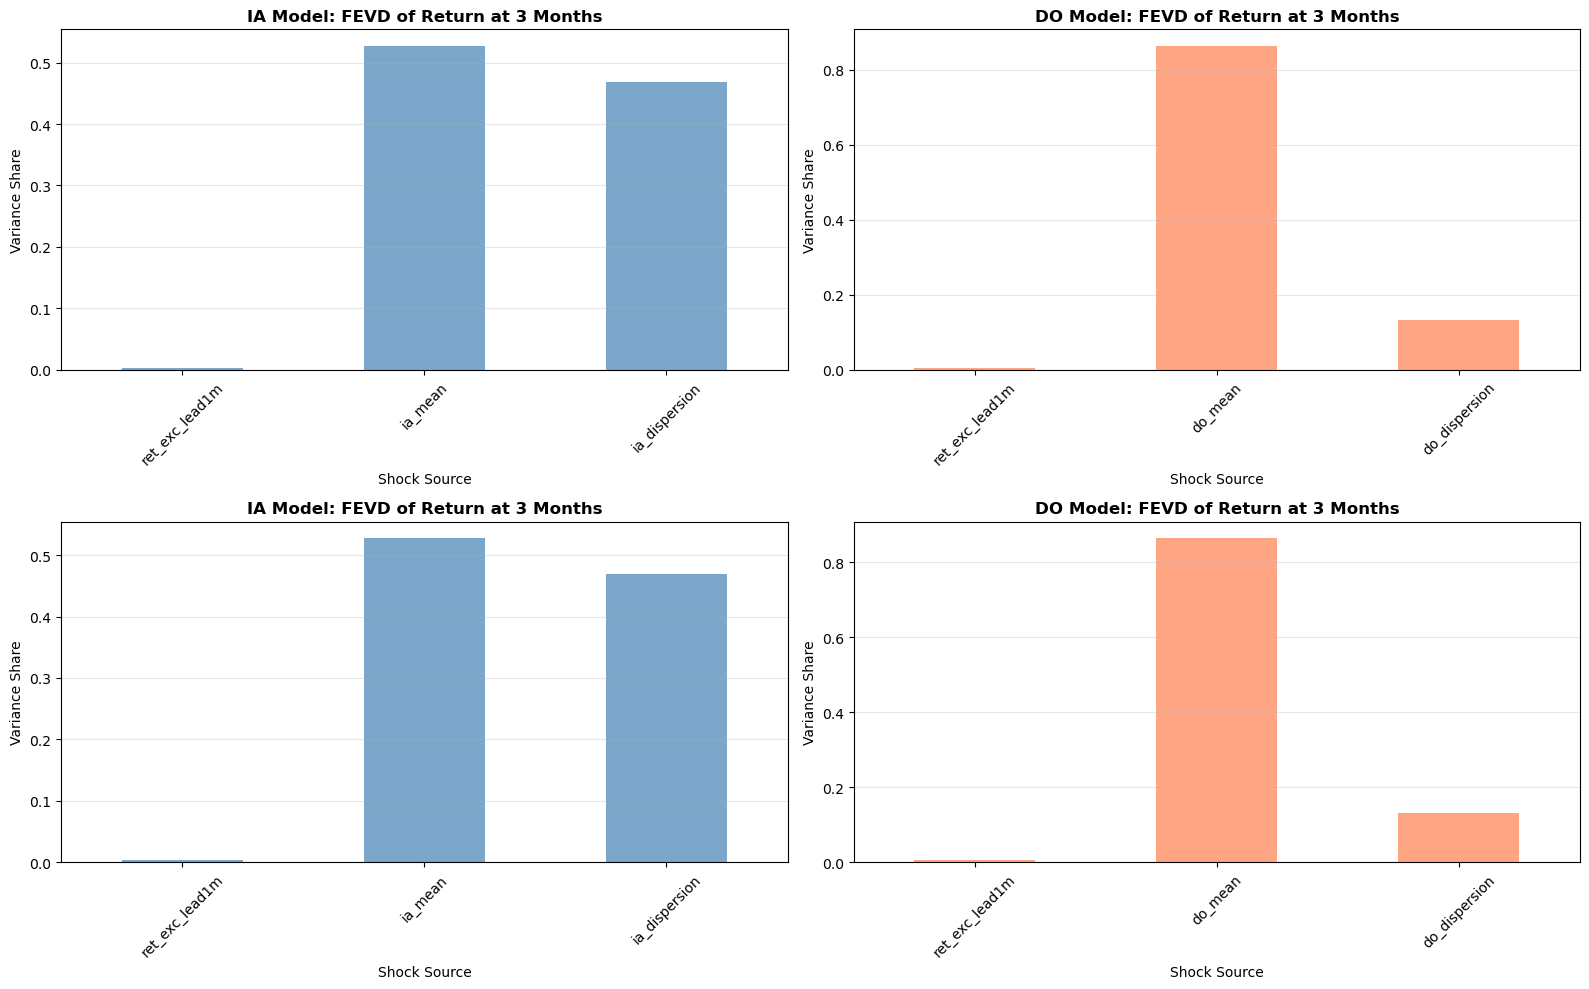


IMPULSE RESPONSE FUNCTIONS - COMPARISON

Computing IRFs up to 3 months

IA Model - Response of returns to dispersion shock:
Shape: (4,), Values:
[0.         0.00087829 0.00223058 0.00314887]

DO Model - Response of returns to dispersion shock:
Shape: (4,), Values:
[ 0.          0.53486777 -0.20990186  0.03547076]


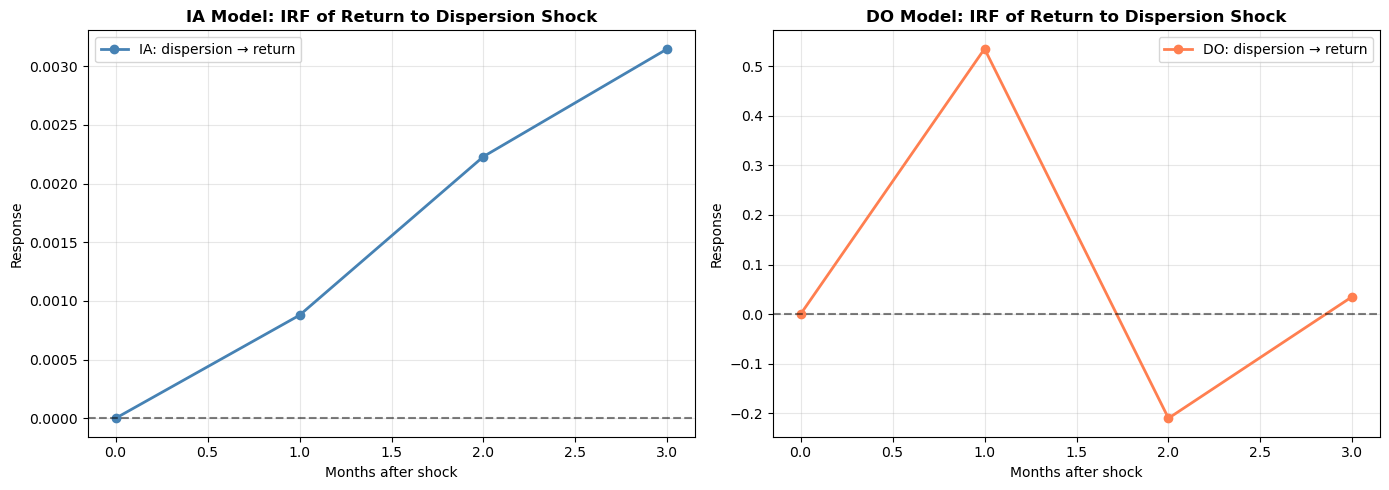


SUMMARY COMPARISON TABLE


,Model,Optimal Lags,Disp→Ret (3m),Disp→Ret (12m),Mean→Ret (3m),Mean→Ret (12m)
0,IA,1,0.469,NaN,0.528,NaN
1,DO,2,0.131,NaN,0.864,NaN



Interpretation:
- Values show the share of return forecast error variance explained by shocks
- Higher values indicate stronger predictive power for future returns
- Comparison reveals whether IA or DO better captures return dynamics
- Note: 12-month horizon not available (max horizon: 3 months)


In [23]:
# Comparative Analysis: IA vs DO VAR Models

print("=" * 80)
print("COMPARATIVE ANALYSIS: IA vs DO VAR MODELS")
print("=" * 80)

# Determine available horizons based on actual data
max_horizon = min(h_ia, h_do)
print(f"\nAvailable horizons: IA model has {h_ia} periods, DO model has {h_do} periods")
print(f"Using maximum common horizon: {max_horizon} months")

# Compare variance decompositions at horizon 3 and min(12, max_horizon)
comparison_horizons = [h for h in [3, 12] if h <= max_horizon]
print(f"Comparison horizons: {comparison_horizons}")

for horizon in comparison_horizons:
    print(f"\n{'=' * 80}")
    print(f"COMPARISON AT HORIZON {horizon} MONTHS")
    print(f"{'=' * 80}")
    
    # IA Model - variance explained by dispersion shock to returns
    if horizon <= h_ia:
        ia_disp_idx = labels_ia.index('ia_dispersion')
        ia_to_ret = fevd_ia.decomp[horizon-1, ret_idx_ia, ia_disp_idx]
        
        ia_mean_idx = labels_ia.index('ia_mean')
        ia_mean_to_ret = fevd_ia.decomp[horizon-1, ret_idx_ia, ia_mean_idx]
        
        print(f"\nIA Model - Impact on Market Return:")
        print(f"  ia_dispersion shock → return: {ia_to_ret:.1%}")
        print(f"  ia_mean shock → return:       {ia_mean_to_ret:.1%}")
    
    # DO Model - variance explained by dispersion shock to returns
    if horizon <= h_do:
        do_disp_idx = labels_do.index('do_dispersion')
        do_to_ret = fevd_do.decomp[horizon-1, ret_idx_do, do_disp_idx]
        
        do_mean_idx = labels_do.index('do_mean')
        do_mean_to_ret = fevd_do.decomp[horizon-1, ret_idx_do, do_mean_idx]
        
        print(f"\nDO Model - Impact on Market Return:")
        print(f"  do_dispersion shock → return: {do_to_ret:.1%}")
        print(f"  do_mean shock → return:       {do_mean_to_ret:.1%}")
    
    # Comparison
    if horizon <= h_ia and horizon <= h_do:
        print(f"\nDifference (IA - DO):")
        print(f"  Dispersion impact: {(ia_to_ret - do_to_ret):.1%}")
        print(f"  Mean impact:       {(ia_mean_to_ret - do_mean_to_ret):.1%}")

# Side-by-side comparison plots - only plot available horizons
plot_horizons = [h for h in [3, min(12, max_horizon)] if h <= max_horizon and h >= 3]
n_horizons = len(plot_horizons)

if n_horizons > 0:
    fig, axes = plt.subplots(n_horizons, 2, figsize=(16, 5 * n_horizons))
    if n_horizons == 1:
        axes = axes.reshape(1, -1)  # Ensure 2D array even with 1 row
    
    for idx, h in enumerate(plot_horizons):
        # Get data for both models
        h_ia_data = fevd_ia.decomp[h-1, ret_idx_ia, :] if h <= h_ia else None
        h_do_data = fevd_do.decomp[h-1, ret_idx_do, :] if h <= h_do else None
        
        # IA Model plot
        if h_ia_data is not None:
            ax = axes[idx, 0]
            pd.Series(h_ia_data, index=labels_ia).plot(kind='bar', ax=ax, color='steelblue', alpha=0.7)
            ax.set_title(f'IA Model: FEVD of Return at {h} Months', fontsize=12, fontweight='bold')
            ax.set_ylabel('Variance Share', fontsize=10)
            ax.set_xlabel('Shock Source', fontsize=10)
            ax.tick_params(axis='x', rotation=45)
            ax.grid(axis='y', alpha=0.3)
        
        # DO Model plot
        if h_do_data is not None:
            ax = axes[idx, 1]
            pd.Series(h_do_data, index=labels_do).plot(kind='bar', ax=ax, color='coral', alpha=0.7)
            ax.set_title(f'DO Model: FEVD of Return at {h} Months', fontsize=12, fontweight='bold')
            ax.set_ylabel('Variance Share', fontsize=10)
            ax.set_xlabel('Shock Source', fontsize=10)
            ax.tick_params(axis='x', rotation=45)
            ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("\nNote: Not enough data points for comparison plots")

# Impulse Response Functions Comparison
print("\n" + "=" * 80)
print("IMPULSE RESPONSE FUNCTIONS - COMPARISON")
print("=" * 80)

# Use the minimum available horizon for IRF comparison
irf_horizon = min(12, max_horizon)
print(f"\nComputing IRFs up to {irf_horizon} months")

# IA Model IRF
irf_ia = var_res_ia.irf(irf_horizon)
print("\nIA Model - Response of returns to dispersion shock:")
irf_ia_disp_to_ret = irf_ia.irfs[:, ret_idx_ia, labels_ia.index('ia_dispersion')]
print(f"Shape: {irf_ia_disp_to_ret.shape}, Values:")
print(irf_ia_disp_to_ret)

# DO Model IRF
irf_do = var_res_do.irf(irf_horizon)
print("\nDO Model - Response of returns to dispersion shock:")
irf_do_disp_to_ret = irf_do.irfs[:, ret_idx_do, labels_do.index('do_dispersion')]
print(f"Shape: {irf_do_disp_to_ret.shape}, Values:")
print(irf_do_disp_to_ret)

# Plot IRFs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Create x-axis for plotting
x_periods = range(len(irf_ia_disp_to_ret))

# IA IRF
axes[0].plot(x_periods, irf_ia_disp_to_ret, marker='o', linewidth=2, color='steelblue', label='IA: dispersion → return')
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0].set_title('IA Model: IRF of Return to Dispersion Shock', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Months after shock', fontsize=10)
axes[0].set_ylabel('Response', fontsize=10)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# DO IRF
axes[1].plot(x_periods, irf_do_disp_to_ret, marker='o', linewidth=2, color='coral', label='DO: dispersion → return')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title('DO Model: IRF of Return to Dispersion Shock', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Months after shock', fontsize=10)
axes[1].set_ylabel('Response', fontsize=10)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary comparison table
print("\n" + "=" * 80)
print("SUMMARY COMPARISON TABLE")
print("=" * 80)

summary_data = {
    'Model': ['IA', 'DO'],
    'Optimal Lags': [p_ia, p_do],
    'Disp→Ret (3m)': [
        fevd_ia.decomp[2, ret_idx_ia, labels_ia.index('ia_dispersion')] if h_ia >= 3 else np.nan,
        fevd_do.decomp[2, ret_idx_do, labels_do.index('do_dispersion')] if h_do >= 3 else np.nan
    ],
    'Disp→Ret (12m)': [
        fevd_ia.decomp[11, ret_idx_ia, labels_ia.index('ia_dispersion')] if h_ia >= 12 else np.nan,
        fevd_do.decomp[11, ret_idx_do, labels_do.index('do_dispersion')] if h_do >= 12 else np.nan
    ],
    'Mean→Ret (3m)': [
        fevd_ia.decomp[2, ret_idx_ia, labels_ia.index('ia_mean')] if h_ia >= 3 else np.nan,
        fevd_do.decomp[2, ret_idx_do, labels_do.index('do_mean')] if h_do >= 3 else np.nan
    ],
    'Mean→Ret (12m)': [
        fevd_ia.decomp[11, ret_idx_ia, labels_ia.index('ia_mean')] if h_ia >= 12 else np.nan,
        fevd_do.decomp[11, ret_idx_do, labels_do.index('do_mean')] if h_do >= 12 else np.nan
    ]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df.round(3))

print("\nInterpretation:")
print("- Values show the share of return forecast error variance explained by shocks")
print("- Higher values indicate stronger predictive power for future returns")
print("- Comparison reveals whether IA or DO better captures return dynamics")
if max_horizon < 12:
    print(f"- Note: 12-month horizon not available (max horizon: {max_horizon} months)")

## Panel Data Models

### Diagnostics

### Set up panel structure

In [24]:
df = df.dropna(subset=['ia_dispersion'])

In [25]:
df['eom'] = pd.to_datetime(df['eom'])
df['ia_do_interaction'] = df['ia_dispersion'] * df['do_dispersion']
df_multi = df.set_index(['id', 'eom']).sort_index()
regressors = ['ia_dispersion', 'do_dispersion', 'ia_do_interaction', 'mkt-rf', 'smb', 'hml', 'rmw', 'cma']

In [26]:
print(df_multi.index.is_monotonic_increasing) 
print(df_multi.index.names)  

True
['id', 'eom']


In [27]:
obs_per_firm = df_multi.groupby('id').size()
obs_per_firm.describe()

count    493.000000
mean     113.539554
std       20.139376
min        6.000000
25%      120.000000
50%      120.000000
75%      120.000000
max      120.000000
dtype: float64

### Winsorize and Scale Variables

In [28]:
df_multi = winsorize_features(df_multi, regressors)

In [29]:
for c in regressors:
    df_multi[c] = df_multi.groupby('id')[c].transform(
        lambda x: (x - x.mean()) / x.std()
    )

In [30]:
df_multi['ret_exc_lead1m'] = (df_multi['ret_exc_lead1m'] - df_multi['ret_exc_lead1m'].mean()) / df_multi['ret_exc_lead1m'].std()

In [31]:
df_multi['ebit_sale'] = (df_multi['ebit_sale'] - df_multi['ebit_sale'].mean()) / df_multi['ebit_sale'].std()

In [32]:
# for c in regressors:
#     df_multi[c] = df_multi.groupby('id')[c].transform(
#         lambda x: (x - x.min()) / (x.max() - x.min())
#     )

### Target: Future returns - Fixed Effects

#### MODEL 1

In [33]:
panel_df = df_multi.dropna(subset=['ret_exc_lead1m'] + regressors)

# Set up dependent and independent variables
y = panel_df['ret_exc_lead1m']
X = panel_df[regressors]
X = sm.add_constant(X)

# Run First Difference regression
fe_model = PanelOLS(y, X, entity_effects=True, time_effects=True)
fe_results = fe_model.fit(cov_type='clustered', debiased=True)
print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:         ret_exc_lead1m   R-squared:                        0.0004
Estimator:                   PanelOLS   R-squared (Between):             -0.0615
No. Observations:               55875   R-squared (Within):              -0.3109
Date:                Mon, Dec 01 2025   R-squared (Overall):             -0.3085
Time:                        14:20:43   Log-likelihood                -7.036e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2.4720
Entities:                         493   P-value                           0.0112
Avg Obs:                       113.34   Distribution:                 F(8,55255)
Min Obs:                       4.0000                                           
Max Obs:                       120.00   F-statistic (robust):             1.2298
                            

The coefficients can be interpreted as effect sizes relative to the historical volatility of monthly excess returns, rather than in raw percentage units. 

A one–standard-deviation increase in IA dispersion predicts a 0.054-standard-deviation increase in next-month excess returns, while DO dispersion contributes 0.042 SD, both statistically strong and meaningfully large for asset-level monthly returns. The negative interaction term (–0.057 SD) again shows that the predictive effect of one dispersion measure weakens when the other is high, indicating substantial overlap in the information they capture.

 Importantly, none of the standard factor exposures (MKT–RF, SMB, HML, RMW, CMA) load significantly in this specification, suggesting that the return patterns associated with dispersion are not explained by conventional risk factors. 
 
 Although the model’s R² remains low, as is typical for forecasting monthly stock returns, the standardized coefficients underscore that dispersion contributes robust incremental predictive power even after accounting for entity and time fixed effects.


#### MODEL 2

In [34]:
regressors = ['ia_dispersion', 'do_dispersion', 'ia_do_interaction']

In [35]:
panel_df = df_multi.dropna(subset=['ret_exc_lead1m'] + regressors)

# Set up dependent and independent variables
y = panel_df['ret_exc_lead1m']
X = panel_df[regressors]
X = sm.add_constant(X)

# Run First Difference regression
fe_model = PanelOLS(y, X, entity_effects=True, time_effects=True)
fe_results = fe_model.fit(cov_type='clustered', debiased=True)
print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:         ret_exc_lead1m   R-squared:                        0.0002
Estimator:                   PanelOLS   R-squared (Between):             -0.0007
No. Observations:               55875   R-squared (Within):               0.0004
Date:                Mon, Dec 01 2025   R-squared (Overall):              0.0004
Time:                        14:20:44   Log-likelihood                -7.036e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3.7497
Entities:                         493   P-value                           0.0105
Avg Obs:                       113.34   Distribution:                 F(3,55260)
Min Obs:                       4.0000                                           
Max Obs:                       120.00   F-statistic (robust):             2.2277
                            

 The results closely mirror the earlier regression: IA and DO dispersion remain positive, highly significant predictors of next-month returns, with effect sizes of 0.054 and 0.042 standard deviations, respectively, and the interaction term stays negative and significant, indicating that the two measures convey overlapping information. 
 
The low R² also remains typical for asset-level return prediction, indicating that standardizing the target affects interpretability but not the underlying pattern of results.

#### MODEL 3

In [36]:
regressors = ['ia_dispersion', 'do_dispersion', 'ia_do_interaction', 'beta_60m']

In [37]:
panel_df = df_multi.dropna(subset=['ret_exc_lead1m'] + regressors)

# Set up dependent and independent variables
y = panel_df['ret_exc_lead1m']
X = panel_df[regressors]
X = sm.add_constant(X)

# Run First Difference regression
fe_model = PanelOLS(y, X, entity_effects=True, time_effects=True)
fe_results = fe_model.fit(cov_type='clustered', debiased=True)
print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:         ret_exc_lead1m   R-squared:                        0.0017
Estimator:                   PanelOLS   R-squared (Between):              0.0678
No. Observations:               53880   R-squared (Within):               0.0019
Date:                Mon, Dec 01 2025   R-squared (Overall):              0.0017
Time:                        14:20:45   Log-likelihood                -6.611e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      23.044
Entities:                         485   P-value                           0.0000
Avg Obs:                       111.09   Distribution:                 F(4,53272)
Min Obs:                       5.0000                                           
Max Obs:                       120.00   F-statistic (robust):             8.9898
                            

#### MODEL 4

In [38]:
regressors = ['ia_dispersion', 'beta_60m']

In [39]:
panel_df = df_multi.dropna(subset=['ret_exc_lead1m'] + regressors)

# Set up dependent and independent variables
y = panel_df['ret_exc_lead1m']
X = panel_df[regressors]
X = sm.add_constant(X)

# Run First Difference regression
fe_model = PanelOLS(y, X, entity_effects=True, time_effects=True)
fe_results = fe_model.fit(cov_type='clustered', debiased=True)
print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:         ret_exc_lead1m   R-squared:                        0.0016
Estimator:                   PanelOLS   R-squared (Between):              0.0733
No. Observations:               53880   R-squared (Within):               0.0015
Date:                Mon, Dec 01 2025   R-squared (Overall):              0.0014
Time:                        14:20:52   Log-likelihood                -6.611e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      43.680
Entities:                         485   P-value                           0.0000
Avg Obs:                       111.09   Distribution:                 F(2,53274)
Min Obs:                       5.0000                                           
Max Obs:                       120.00   F-statistic (robust):             15.582
                            

#### MODEL 5

In [40]:
regressors = ['do_dispersion', 'beta_60m']

In [41]:
panel_df = df_multi.dropna(subset=['ret_exc_lead1m'] + regressors)

# Set up dependent and independent variables
y = panel_df['ret_exc_lead1m']
X = panel_df[regressors]
X = sm.add_constant(X)

# Run First Difference regression
fe_model = PanelOLS(y, X, entity_effects=True, time_effects=True)
fe_results = fe_model.fit(cov_type='clustered', debiased=True)
print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:         ret_exc_lead1m   R-squared:                        0.0016
Estimator:                   PanelOLS   R-squared (Between):              0.0691
No. Observations:               53880   R-squared (Within):               0.0020
Date:                Mon, Dec 01 2025   R-squared (Overall):              0.0018
Time:                        14:20:53   Log-likelihood                -6.611e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      41.606
Entities:                         485   P-value                           0.0000
Avg Obs:                       111.09   Distribution:                 F(2,53274)
Min Obs:                       5.0000                                           
Max Obs:                       120.00   F-statistic (robust):             13.906
                            

#### MODEL 6

In [42]:
regressors = ['ia_dispersion', 'mkt-rf', 'smb', 'hml', 'rmw', 'cma']

In [43]:
panel_df = df_multi.dropna(subset=['ret_exc_lead1m'] + regressors)

# Set up dependent and independent variables
y = panel_df['ret_exc_lead1m']
X = panel_df[regressors]
X = sm.add_constant(X)

# Run First Difference regression
fe_model = PanelOLS(y, X, entity_effects=True, time_effects=True)
fe_results = fe_model.fit(cov_type='clustered', debiased=True)
print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:         ret_exc_lead1m   R-squared:                        0.0003
Estimator:                   PanelOLS   R-squared (Between):             -0.0624
No. Observations:               55875   R-squared (Within):              -0.3097
Date:                Mon, Dec 01 2025   R-squared (Overall):             -0.3074
Time:                        14:20:53   Log-likelihood                -7.036e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2.9207
Entities:                         493   P-value                           0.0075
Avg Obs:                       113.34   Distribution:                 F(6,55257)
Min Obs:                       4.0000                                           
Max Obs:                       120.00   F-statistic (robust):             1.4425
                            

#### MODEL 7

In [44]:
regressors = ['do_dispersion', 'mkt-rf', 'smb', 'hml', 'rmw', 'cma']

In [45]:
panel_df = df_multi.dropna(subset=['ret_exc_lead1m'] + regressors)

# Set up dependent and independent variables
y = panel_df['ret_exc_lead1m']
X = panel_df[regressors]
X = sm.add_constant(X)

# Run First Difference regression
fe_model = PanelOLS(y, X, entity_effects=True, time_effects=True)
fe_results = fe_model.fit(cov_type='clustered', debiased=True)
print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:         ret_exc_lead1m   R-squared:                        0.0003
Estimator:                   PanelOLS   R-squared (Between):             -0.0615
No. Observations:               55875   R-squared (Within):              -0.3075
Date:                Mon, Dec 01 2025   R-squared (Overall):             -0.3052
Time:                        14:20:54   Log-likelihood                -7.036e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2.6179
Entities:                         493   P-value                           0.0154
Avg Obs:                       113.34   Distribution:                 F(6,55257)
Min Obs:                       4.0000                                           
Max Obs:                       120.00   F-statistic (robust):             1.2498
                            

### Target: Future returns - Fama-Macbeth

#### MODEL 1

In [46]:
# controls = ['size_grp', 'ret_3_1', 'beta_60m', 'mispricing_perf']  # Example controls: size, book-to-market, momentum, beta
regressors = ['ia_dispersion', 'do_dispersion', 'ia_do_interaction']

# Prepare panel data
panel_df = df_multi.dropna(subset=['ret_exc_lead1m'] + regressors)
y = panel_df['ret_exc_lead1m']
X = panel_df[regressors]
X = sm.add_constant(X)

# Fama-MacBeth regression
fm_model = FamaMacBeth(y, X)
fm_results = fm_model.fit(cov_type='robust')
print(fm_results.summary)

                             FamaMacBeth Estimation Summary                            
Dep. Variable:                ret_exc_lead1m   R-squared:                        0.0002
Estimator:                       FamaMacBeth   R-squared (Between):             -0.0008
No. Observations:                      55875   R-squared (Within):               0.0004
Date:                       Mon, Dec 01 2025   R-squared (Overall):              0.0002
Time:                               14:20:54   Log-likelihood                -7.928e+04
Cov. Estimator:    Fama-MacBeth Standard Cov                                           
                                               F-statistic:                      3.5047
Entities:                                493   P-value                           0.0147
Avg Obs:                              113.34   Distribution:                 F(3,55871)
Min Obs:                              4.0000                                           
Max Obs:                        

#### MODEL 2

In [47]:
controls = ['mkt-rf', 'smb', 'hml', 'rmw', 'cma']  # Example controls: size, book-to-market, momentum, beta
regressors = ['ia_dispersion', 'do_dispersion', 'ia_do_interaction'] + controls

# Prepare panel data
panel_df = df_multi.dropna(subset=['ret_exc_lead1m'] + regressors)
y = panel_df['ret_exc_lead1m']
X = panel_df[regressors]
X = sm.add_constant(X)

# Fama-MacBeth regression
fm_model = FamaMacBeth(y, X)
fm_results = fm_model.fit(cov_type='robust')
print(fm_results.summary)

                             FamaMacBeth Estimation Summary                            
Dep. Variable:                ret_exc_lead1m   R-squared:                       -0.9161
Estimator:                       FamaMacBeth   R-squared (Between):             -0.9879
No. Observations:                      55875   R-squared (Within):              -0.9117
Date:                       Mon, Dec 01 2025   R-squared (Overall):             -0.9161
Time:                               14:20:55   Log-likelihood                -9.745e+04
Cov. Estimator:    Fama-MacBeth Standard Cov                                           
                                               F-statistic:                     -3338.8
Entities:                                493   P-value                           1.0000
Avg Obs:                              113.34   Distribution:                 F(8,55866)
Min Obs:                              4.0000                                           
Max Obs:                        

### Target: Future earnings - Fixed Effects

#### MODEL 1

In [48]:
# Create lagged regressors
regressors =  ['ia_dispersion', 'do_dispersion', 'ia_do_interaction']

panel = df_multi.dropna(subset=['ebit_sale'] + regressors)
# Prepare dependent and independent variables
y = panel['ebit_sale']
X = panel[regressors]
X = sm.add_constant(X)

# Run fixed effects regression
fe_model = PanelOLS(y, X, entity_effects=True, time_effects=True)
fe_results = fe_model.fit(cov_type='clustered')
print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              ebit_sale   R-squared:                        0.0046
Estimator:                   PanelOLS   R-squared (Between):             -0.0003
No. Observations:               55833   R-squared (Within):               0.0018
Date:                Mon, Dec 01 2025   R-squared (Overall):              0.0017
Time:                        14:20:56   Log-likelihood                -7.634e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      84.566
Entities:                         492   P-value                           0.0000
Avg Obs:                       113.48   Distribution:                 F(3,55219)
Min Obs:                       6.0000                                           
Max Obs:                       120.00   F-statistic (robust):             77.985
                            

#### MODEL 2

In [49]:
# Create lagged regressors
regressors = ['ia_dispersion', 'do_dispersion', 'ia_do_interaction', 'mkt-rf', 'smb', 'hml', 'rmw', 'cma']

panel = df_multi.dropna(subset=['ebit_sale'] + regressors)
# Prepare dependent and independent variables
y = panel['ebit_sale']
X = panel[regressors]
X = sm.add_constant(X)

# Run fixed effects regression
fe_model = PanelOLS(y, X, entity_effects=True, time_effects=True)
fe_results = fe_model.fit(cov_type='clustered')
print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              ebit_sale   R-squared:                        0.0046
Estimator:                   PanelOLS   R-squared (Between):             -0.0004
No. Observations:               55833   R-squared (Within):              -0.0063
Date:                Mon, Dec 01 2025   R-squared (Overall):             -0.0057
Time:                        14:20:57   Log-likelihood                -7.634e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      31.852
Entities:                         492   P-value                           0.0000
Avg Obs:                       113.48   Distribution:                 F(8,55214)
Min Obs:                       6.0000                                           
Max Obs:                       120.00   F-statistic (robust):             29.581
                            

#### MODEL 3

In [50]:
# Create lagged regressors
regressors = ['ia_dispersion', 'do_dispersion', 'ia_do_interaction', 'mkt-rf', 'smb', 'hml', 'rmw', 'cma', 'beta_60m']

panel = df_multi.dropna(subset=['ebit_sale'] + regressors)
# Prepare dependent and independent variables
y = panel['ebit_sale']
X = panel[regressors]
X = sm.add_constant(X)

# Run fixed effects regression
fe_model = PanelOLS(y, X, entity_effects=True, time_effects=True)
fe_results = fe_model.fit(cov_type='clustered')
print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              ebit_sale   R-squared:                        0.0055
Estimator:                   PanelOLS   R-squared (Between):              0.0283
No. Observations:               53801   R-squared (Within):              -0.0082
Date:                Mon, Dec 01 2025   R-squared (Overall):             -0.0044
Time:                        14:20:58   Log-likelihood                -7.286e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      32.957
Entities:                         484   P-value                           0.0000
Avg Obs:                       111.16   Distribution:                 F(9,53189)
Min Obs:                       5.0000                                           
Max Obs:                       120.00   F-statistic (robust):             35.313
                            

#### MODEL 4

In [51]:
# Create lagged regressors
regressors = ['ia_dispersion', 'do_dispersion', 'ia_do_interaction', 'mkt-rf', 'smb', 'hml', 'rmw', 'cma', 'beta_60m']
panel = df_multi.dropna(subset=['ebit_sale'] + regressors)
# Prepare dependent and independent variables
y = panel['ebit_sale']
X = panel[regressors]
X = sm.add_constant(X)

# Run fixed effects regression
fe_model = PanelOLS(y, X, entity_effects=True, time_effects=True)
fe_results = fe_model.fit(cov_type='clustered')
print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              ebit_sale   R-squared:                        0.0055
Estimator:                   PanelOLS   R-squared (Between):              0.0283
No. Observations:               53801   R-squared (Within):              -0.0082
Date:                Mon, Dec 01 2025   R-squared (Overall):             -0.0044
Time:                        14:21:03   Log-likelihood                -7.286e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      32.957
Entities:                         484   P-value                           0.0000
Avg Obs:                       111.16   Distribution:                 F(9,53189)
Min Obs:                       5.0000                                           
Max Obs:                       120.00   F-statistic (robust):             35.313
                            

#### MODEL 5

In [52]:
# Create lagged regressors
regressors = ['ia_dispersion', 'beta_60m']
    

panel = df_multi.dropna(subset=['ebit_sale'] + regressors)
# Prepare dependent and independent variables
y = panel['ebit_sale']
X = panel[regressors]
X = sm.add_constant(X)

# Run fixed effects regression
fe_model = PanelOLS(y, X, entity_effects=True, time_effects=True)
fe_results = fe_model.fit(cov_type='clustered')
print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              ebit_sale   R-squared:                        0.0055
Estimator:                   PanelOLS   R-squared (Between):              0.0258
No. Observations:               53801   R-squared (Within):               0.0035
Date:                Mon, Dec 01 2025   R-squared (Overall):              0.0062
Time:                        14:21:04   Log-likelihood                -7.286e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      147.55
Entities:                         484   P-value                           0.0000
Avg Obs:                       111.16   Distribution:                 F(2,53196)
Min Obs:                       5.0000                                           
Max Obs:                       120.00   F-statistic (robust):             72.944
                            

#### MODEL 6

In [53]:
# Create lagged regressors
regressors = ['do_dispersion', 'beta_60m']
panel = df_multi.dropna(subset=['ebit_sale'] + regressors)
# Prepare dependent and independent variables
y = panel['ebit_sale']
X = panel[regressors]
X = sm.add_constant(X)

# Run fixed effects regression
fe_model = PanelOLS(y, X, entity_effects=True, time_effects=True)
fe_results = fe_model.fit(cov_type='clustered')
print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              ebit_sale   R-squared:                        0.0032
Estimator:                   PanelOLS   R-squared (Between):              0.0241
No. Observations:               53801   R-squared (Within):               0.0029
Date:                Mon, Dec 01 2025   R-squared (Overall):              0.0055
Time:                        14:21:05   Log-likelihood                -7.292e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      84.427
Entities:                         484   P-value                           0.0000
Avg Obs:                       111.16   Distribution:                 F(2,53196)
Min Obs:                       5.0000                                           
Max Obs:                       120.00   F-statistic (robust):             117.43
                            

### Target: Future earnings - Fama-Macbeth

#### MODEL 1

In [54]:
# Create lagged regressors
regressors = ['ia_dispersion', 'do_dispersion', 'ia_do_interaction']
panel = df_multi.dropna(subset=['ebit_sale'] + regressors)
# Prepare dependent and independent variables
y = panel['ebit_sale']
X = panel[regressors]
X = sm.add_constant(X)

# Run fixed effects regression
fe_model = FamaMacBeth(y, X)
fe_results = fe_model.fit()
print(fe_results.summary)

                             FamaMacBeth Estimation Summary                            
Dep. Variable:                     ebit_sale   R-squared:                       -0.0269
Estimator:                       FamaMacBeth   R-squared (Between):             -0.0308
No. Observations:                      55833   R-squared (Within):              -0.0254
Date:                       Mon, Dec 01 2025   R-squared (Overall):             -0.0269
Time:                               14:21:06   Log-likelihood                -7.996e+04
Cov. Estimator:    Fama-MacBeth Standard Cov                                           
                                               F-statistic:                     -486.85
Entities:                                492   P-value                           1.0000
Avg Obs:                              113.48   Distribution:                 F(3,55829)
Min Obs:                              6.0000                                           
Max Obs:                        

#### MODEL 2

In [55]:
# Create lagged regressors
regrresors = ['ia_dispersion', 'do_dispersion', 'ia_do_interaction', 'mkt-rf', 'smb', 'hml', 'rmw', 'cma']
panel = df_multi.dropna(subset=['ebit_sale'] + regressors)
# Prepare dependent and independent variables
y = panel['ebit_sale']
X = panel[regressors]
X = sm.add_constant(X)

# Run fixed effects regression
fe_model = FamaMacBeth(y, X)
fe_results = fe_model.fit()
print(fe_results.summary)

                             FamaMacBeth Estimation Summary                            
Dep. Variable:                     ebit_sale   R-squared:                       -0.0269
Estimator:                       FamaMacBeth   R-squared (Between):             -0.0308
No. Observations:                      55833   R-squared (Within):              -0.0254
Date:                       Mon, Dec 01 2025   R-squared (Overall):             -0.0269
Time:                               14:21:06   Log-likelihood                -7.996e+04
Cov. Estimator:    Fama-MacBeth Standard Cov                                           
                                               F-statistic:                     -486.85
Entities:                                492   P-value                           1.0000
Avg Obs:                              113.48   Distribution:                 F(3,55829)
Min Obs:                              6.0000                                           
Max Obs:                        

#### MODEL 3

In [56]:
# Create lagged regressors
regressors = ['ia_dispersion', 'do_dispersion', 'ia_do_interaction', 'mkt-rf', 'smb', 'hml', 'rmw', 'cma', 'beta_60m']
panel = df_multi.dropna(subset=['ebit_sale'] + regressors)
# Prepare dependent and independent variables
y = panel['ebit_sale']
X = panel[regressors]
X = sm.add_constant(X)

# Run fixed effects regression
fe_model = FamaMacBeth(y, X)
fe_results = fe_model.fit()
print(fe_results.summary)

                             FamaMacBeth Estimation Summary                            
Dep. Variable:                     ebit_sale   R-squared:                       -21.728
Estimator:                       FamaMacBeth   R-squared (Between):             -1.7017
No. Observations:                      53801   R-squared (Within):              -23.740
Date:                       Mon, Dec 01 2025   R-squared (Overall):             -21.728
Time:                               14:21:07   Log-likelihood                -1.597e+05
Cov. Estimator:    Fama-MacBeth Standard Cov                                           
                                               F-statistic:                     -5713.8
Entities:                                484   P-value                           1.0000
Avg Obs:                              111.16   Distribution:                 F(9,53791)
Min Obs:                              5.0000                                           
Max Obs:                        

#### MODEL 4

In [57]:
# Create lagged regressors
regressors = ['ia_dispersion', 'beta_60m'] 
panel = df_multi.dropna(subset=['ebit_sale'] + regressors)
# Prepare dependent and independent variables
y = panel['ebit_sale']
X = panel[regressors]
X = sm.add_constant(X)

# Run fixed effects regression
fe_model = FamaMacBeth(y, X)
fe_results = fe_model.fit()
print(fe_results.summary)

                             FamaMacBeth Estimation Summary                            
Dep. Variable:                     ebit_sale   R-squared:                        0.0006
Estimator:                       FamaMacBeth   R-squared (Between):              0.0217
No. Observations:                      53801   R-squared (Within):              -0.0019
Date:                       Mon, Dec 01 2025   R-squared (Overall):              0.0006
Time:                               14:21:08   Log-likelihood                -7.562e+04
Cov. Estimator:    Fama-MacBeth Standard Cov                                           
                                               F-statistic:                      14.969
Entities:                                484   P-value                           0.0000
Avg Obs:                              111.16   Distribution:                 F(2,53798)
Min Obs:                              5.0000                                           
Max Obs:                        

#### MODEL 5

In [58]:
# Create lagged regressors
regressors = ['do_dispersion', 'beta_60m'] 
panel = df_multi.dropna(subset=['ebit_sale'] + regressors)
# Prepare dependent and independent variables
y = panel['ebit_sale']
X = panel[regressors]
X = sm.add_constant(X)

# Run fixed effects regression
fe_model = FamaMacBeth(y, X)
fe_results = fe_model.fit()
print(fe_results.summary)

                             FamaMacBeth Estimation Summary                            
Dep. Variable:                     ebit_sale   R-squared:                       -0.0019
Estimator:                       FamaMacBeth   R-squared (Between):              0.0204
No. Observations:                      53801   R-squared (Within):              -0.0048
Date:                       Mon, Dec 01 2025   R-squared (Overall):             -0.0019
Time:                               14:21:11   Log-likelihood                -7.568e+04
Cov. Estimator:    Fama-MacBeth Standard Cov                                           
                                               F-statistic:                     -51.581
Entities:                                484   P-value                           1.0000
Avg Obs:                              111.16   Distribution:                 F(2,53798)
Min Obs:                              5.0000                                           
Max Obs:                        

## Portfolio Analysis

### Decile Analysis

In [59]:
for col in ['ia_dispersion', 'do_dispersion', 'ia_do_interaction']:
    df[f'{col}_lag1'] = df.groupby('id')[col].shift(1)

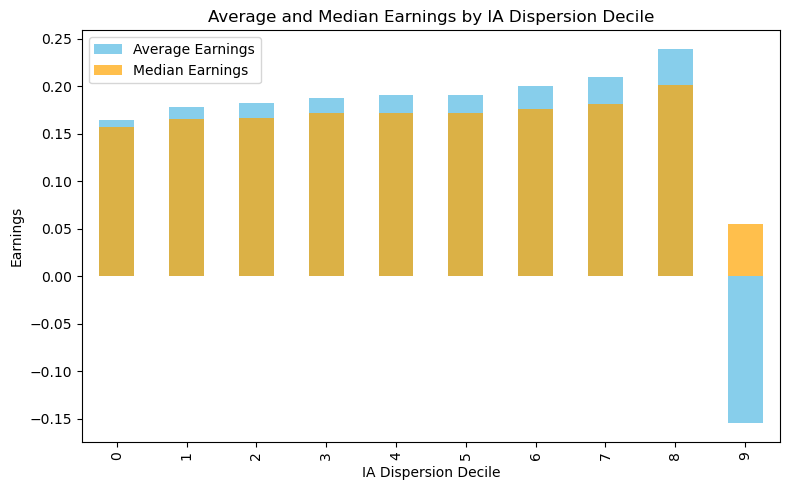

In [60]:
# Plot average and median returns for each decile of ia_dispersion

df['ia_decile'] = df.groupby('eom')['ia_dispersion'].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')
)
decile_stats = df.groupby('ia_decile')['ebit_sale'].agg(['mean', 'median'])

fig, ax = plt.subplots(figsize=(8, 5))
decile_stats['mean'].plot(kind='bar', ax=ax, color='skyblue', label='Average Earnings')
decile_stats['median'].plot(kind='bar', ax=ax, color='orange', alpha=0.7, label='Median Earnings')
ax.set_xlabel('IA Dispersion Decile')
ax.set_ylabel('Earnings')
ax.set_title('Average and Median Earnings by IA Dispersion Decile')
ax.legend()
plt.tight_layout()
plt.show()

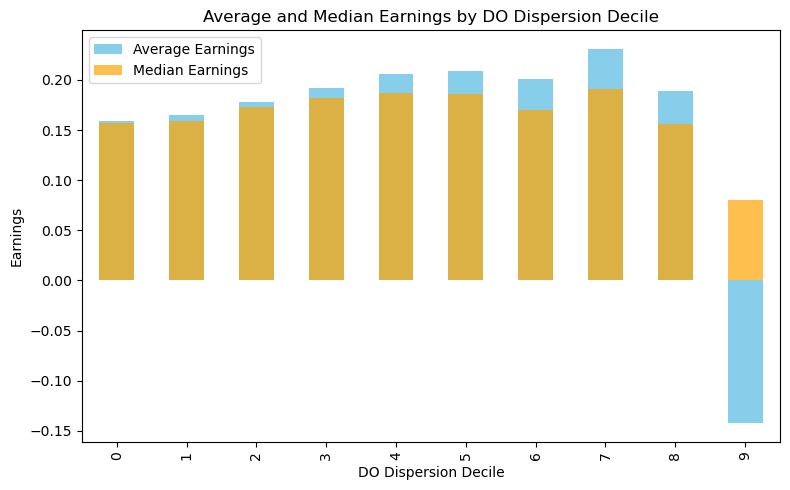

In [61]:
# Plot average and median returns for each decile of ia_dispersion_lag1

df['do_decile'] = df.groupby('eom')['do_dispersion'].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')
)
decile_stats = df.groupby('do_decile')['ebit_sale'].agg(['mean', 'median'])

fig, ax = plt.subplots(figsize=(8, 5))
decile_stats['mean'].plot(kind='bar', ax=ax, color='skyblue', label='Average Earnings')
decile_stats['median'].plot(kind='bar', ax=ax, color='orange', alpha=0.7, label='Median Earnings')
ax.set_xlabel('DO Dispersion Decile')
ax.set_ylabel('Earnings')
ax.set_title('Average and Median Earnings by DO Dispersion Decile')
ax.legend()
plt.tight_layout()
plt.show()

In [62]:
df[['ebit_sale', 'ret_exc_lead1m']].corr()

,ebit_sale,ret_exc_lead1m
ebit_sale,1.000000,0.004973
ret_exc_lead1m,0.004973,1.000000


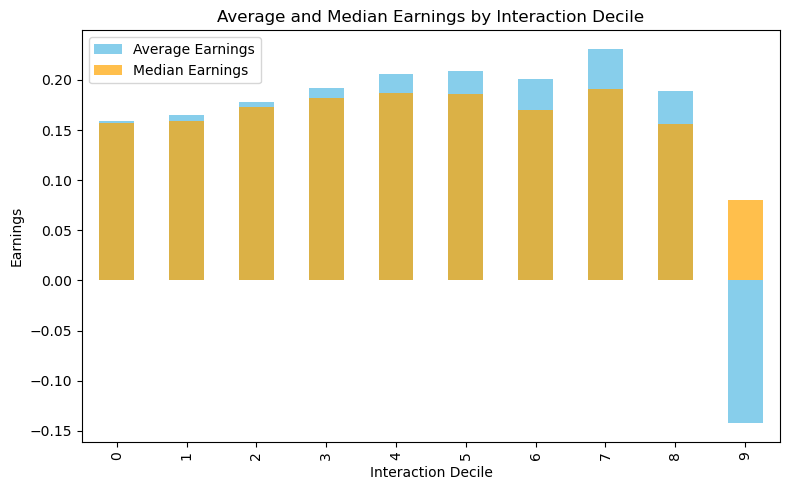

In [63]:
# Plot average and median returns for each decile of ia_dispersion_lag1

df['interaction_decile'] = df.groupby('eom')['do_dispersion'].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')
)
decile_stats = df.groupby('interaction_decile')['ebit_sale'].agg(['mean', 'median'])

fig, ax = plt.subplots(figsize=(8, 5))
decile_stats['mean'].plot(kind='bar', ax=ax, color='skyblue', label='Average Earnings')
decile_stats['median'].plot(kind='bar', ax=ax, color='orange', alpha=0.7, label='Median Earnings')
ax.set_xlabel('Interaction Decile')
ax.set_ylabel('Earnings')
ax.set_title('Average and Median Earnings by Interaction Decile')
ax.legend()
plt.tight_layout()
plt.show()

Unexpectedly, as our previous analysis suggested that the measures are highly correlated, we can se that the mean and median returns of the deciles of all the measures are similar in trends and also in magnitude. 

Moreover, from these plots and our previous anlalysis, it seems that both measures can be used to build portfolios that deliver high returns.

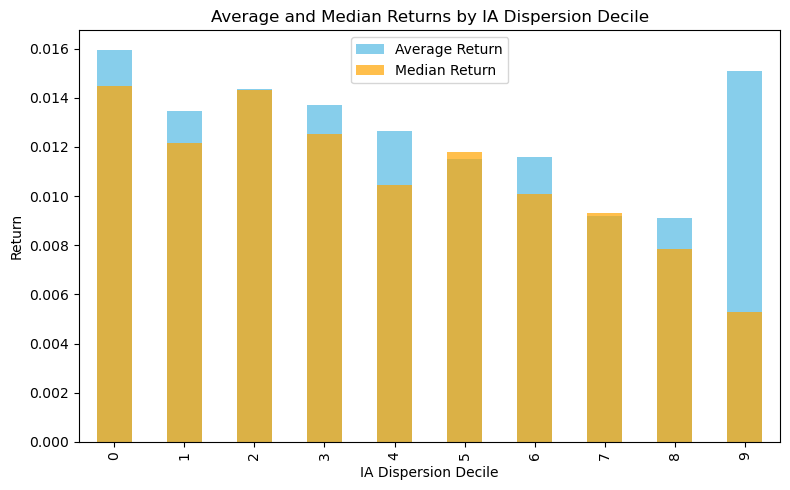

In [64]:
# Plot average and median returns for each decile of ia_dispersion

df['ia_decile'] = df.groupby('eom')['ia_dispersion'].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')
)
decile_stats = df.groupby('ia_decile')['ret_exc_lead1m'].agg(['mean', 'median'])

fig, ax = plt.subplots(figsize=(8, 5))
decile_stats['mean'].plot(kind='bar', ax=ax, color='skyblue', label='Average Return')
decile_stats['median'].plot(kind='bar', ax=ax, color='orange', alpha=0.7, label='Median Return')
ax.set_xlabel('IA Dispersion Decile')
ax.set_ylabel('Return')
ax.set_title('Average and Median Returns by IA Dispersion Decile')
ax.legend()
plt.tight_layout()
plt.show()

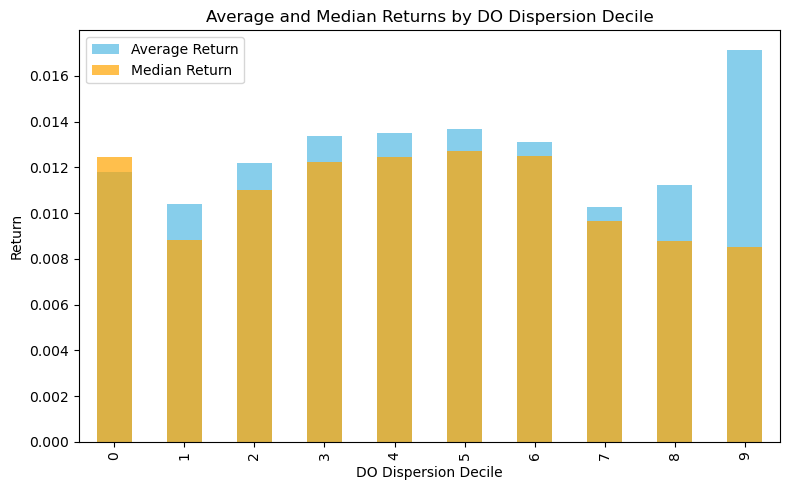

In [65]:
# Plot average and median returns for each decile of ia_dispersion

df['do_decile'] = df.groupby('eom')['do_dispersion'].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')
)
decile_stats = df.groupby('do_decile')['ret_exc_lead1m'].agg(['mean', 'median'])

fig, ax = plt.subplots(figsize=(8, 5))
decile_stats['mean'].plot(kind='bar', ax=ax, color='skyblue', label='Average Return')
decile_stats['median'].plot(kind='bar', ax=ax, color='orange', alpha=0.7, label='Median Return')
ax.set_xlabel('DO Dispersion Decile')
ax.set_ylabel('Return')
ax.set_title('Average and Median Returns by DO Dispersion Decile')
ax.legend()
plt.tight_layout()
plt.show()

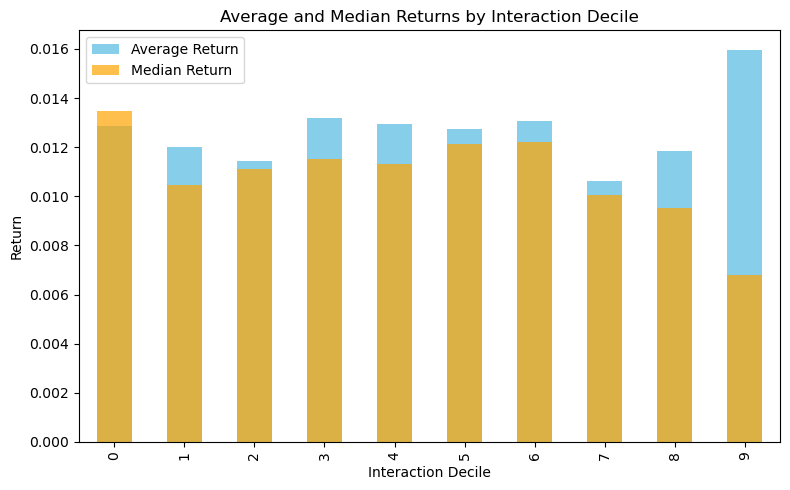

In [66]:
# Plot average and median returns for each decile of ia_dispersion

df['interaction_decile'] = df.groupby('eom')['ia_do_interaction'].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')
)
decile_stats = df.groupby('interaction_decile')['ret_exc_lead1m'].agg(['mean', 'median'])

fig, ax = plt.subplots(figsize=(8, 5))
decile_stats['mean'].plot(kind='bar', ax=ax, color='skyblue', label='Average Return')
decile_stats['median'].plot(kind='bar', ax=ax, color='orange', alpha=0.7, label='Median Return')
ax.set_xlabel('Interaction Decile')
ax.set_ylabel('Return')
ax.set_title('Average and Median Returns by Interaction Decile')
ax.legend()
plt.tight_layout()
plt.show()

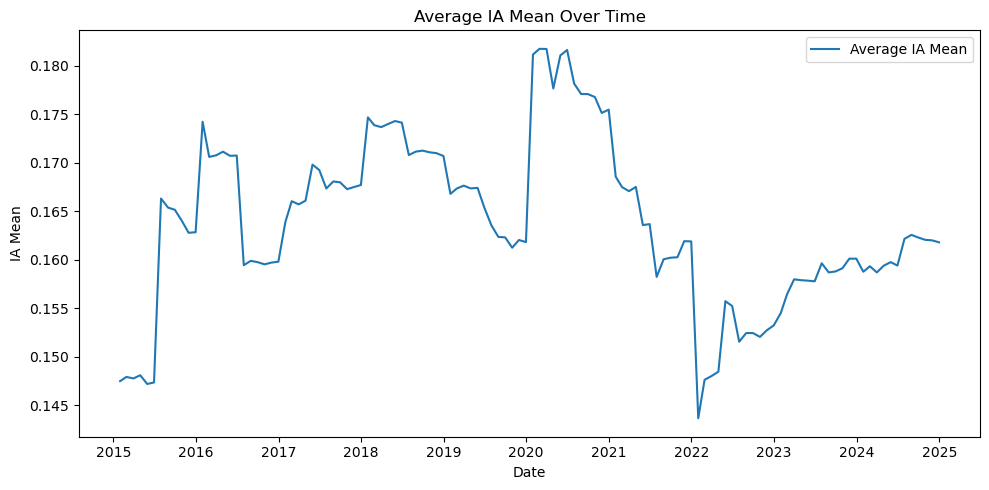

In [67]:
df_multi_grouped = df_multi.groupby('eom')['ia_mean'].mean()
plt.figure(figsize=(10, 5))
plt.plot(df_multi_grouped.index, df_multi_grouped.values, label='Average IA Mean')
plt.xlabel('Date')
plt.ylabel('IA Mean')
plt.title('Average IA Mean Over Time')
plt.legend()
plt.tight_layout()
plt.show()

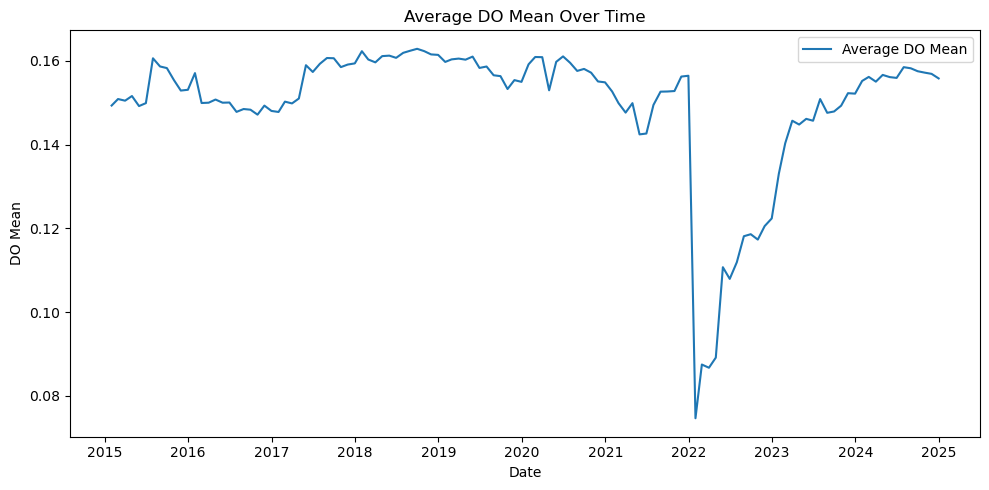

In [68]:
df_multi_grouped = df_multi.groupby('eom')['do_mean'].mean()
plt.figure(figsize=(10, 5))
plt.plot(df_multi_grouped.index, df_multi_grouped.values, label='Average DO Mean')
plt.xlabel('Date')
plt.ylabel('DO Mean')
plt.title('Average DO Mean Over Time')
plt.legend()
plt.tight_layout()
plt.show()

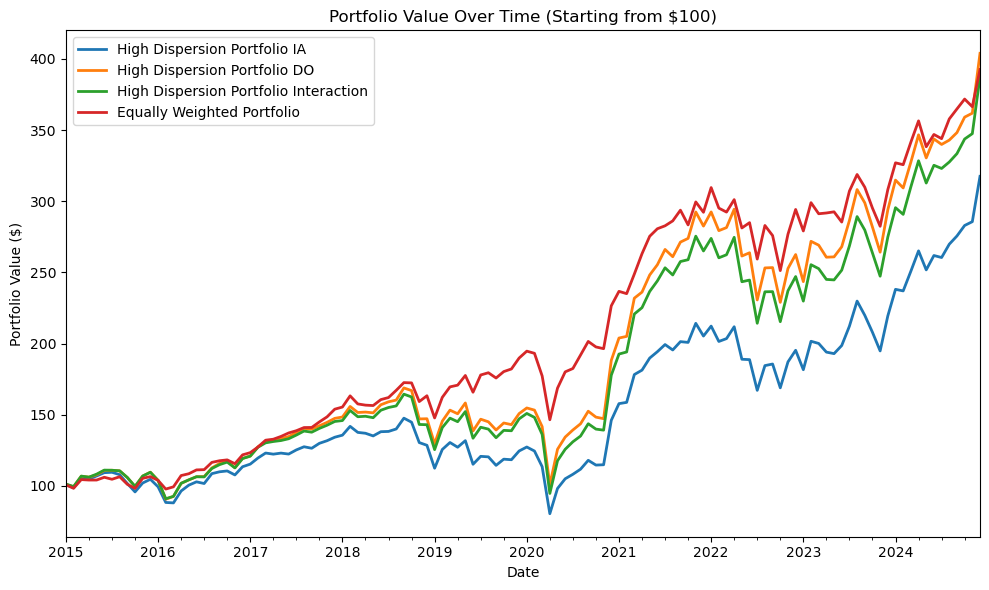

Final value (High Dispersion IA): 285.6334628649428
Final value (High Dispersion DO): 361.8835748993411
Final value (High Dispersion Interaction): 347.49753018291875
Final value (Equally Weighted): 366.4240318895379


In [71]:
# Create a portfolio that buys all stocks in the highest 20% decile of ia_dispersion
df['ia_decile'] = df.groupby('eom')['ia_dispersion'].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates='drop')
)

df['do_decile'] = df.groupby('eom')['do_dispersion'].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates='drop')
)

df['interaction_decile'] = df.groupby('eom')['ia_do_interaction'].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates='drop')
)
# High-dispersion portfolio: top decile (decile == 4)
high_disp_port_ia = df[df['ia_decile'] == 4].groupby('eom')['ret_exc_lead1m'].mean()

high_disp_port_do = df[df['do_decile'] == 4].groupby('eom')['ret_exc_lead1m'].mean()

high_disp_port_interaction = df[df['interaction_decile'] == 4].groupby('eom')['ret_exc_lead1m'].mean()
# Equally weighted portfolio: all stocks
ew_port = df.groupby('eom')['ret_exc_lead1m'].mean()

# Portfolio evolution starting from $100
initial_value = 100
high_disp_value_ia = initial_value * (1 + high_disp_port_ia).cumprod()
high_disp_value_do = initial_value * (1 + high_disp_port_do).cumprod()
high_disp_value_interaction = initial_value * (1 + high_disp_port_interaction).cumprod()
ew_value = initial_value * (1 + ew_port).cumprod()

plt.figure(figsize=(10, 6))
high_disp_value_ia.plot(label='High Dispersion Portfolio IA', lw=2)
high_disp_value_do.plot(label='High Dispersion Portfolio DO', lw=2)
high_disp_value_interaction.plot(label='High Dispersion Portfolio Interaction', lw=2)
ew_value.plot(label='Equally Weighted Portfolio', lw=2)
plt.title('Portfolio Value Over Time (Starting from $100)')
plt.ylabel('Portfolio Value ($)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

print('Final value (High Dispersion IA):', high_disp_value_ia.iloc[-2])
print('Final value (High Dispersion DO):', high_disp_value_do.iloc[-2])
print('Final value (High Dispersion Interaction):', high_disp_value_interaction.iloc[-2])
print('Final value (Equally Weighted):', ew_value.iloc[-2])

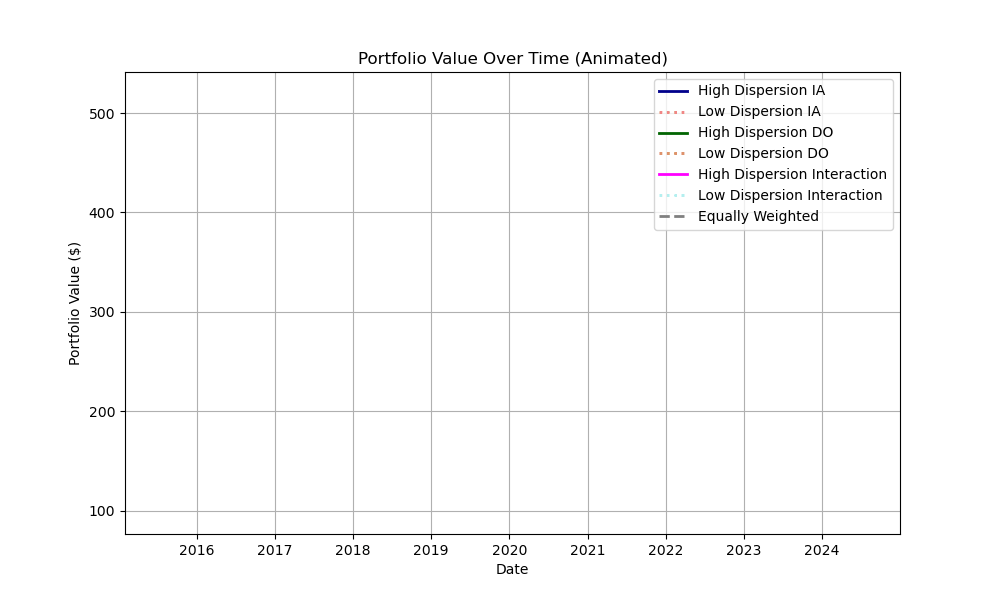

In [70]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import Image
import numpy as np

# Prepare data (drop missing)
high_disp_port_ia = df[df['ia_decile'] == 4].groupby('eom')['ret_exc_lead1m'].mean().dropna()
low_disp_port_ia = df[df['ia_decile'] == 0].groupby('eom')['ret_exc_lead1m'].mean().dropna()
high_disp_port_do = df[df['do_decile'] == 4].groupby('eom')['ret_exc_lead1m'].mean().dropna()
low_disp_port_do = df[df['do_decile'] == 0].groupby('eom')['ret_exc_lead1m'].mean().dropna()
high_disp_port_interaction = df[df['interaction_decile'] == 4].groupby('eom')['ret_exc_lead1m'].mean().dropna()
low_disp_port_interaction = df[df['interaction_decile'] == 0].groupby('eom')['ret_exc_lead1m'].mean().dropna()
ew_port = df.groupby('eom')['ret_exc_lead1m'].mean().dropna()
initial_value = 100

high_disp_value_ia = initial_value * (1 + high_disp_port_ia).cumprod()
low_disp_value_ia = initial_value * (1 + low_disp_port_ia).cumprod()
high_disp_value_do = initial_value * (1 + high_disp_port_do).cumprod()
low_disp_value_do = initial_value * (1 + low_disp_port_do).cumprod()
high_disp_value_interaction = initial_value * (1 + high_disp_port_interaction).cumprod()
low_disp_value_interaction = initial_value * (1 + low_disp_port_interaction).cumprod()
ew_value = initial_value * (1 + ew_port).cumprod()

dates = ew_value.index

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('Portfolio Value Over Time (Animated)')
ax.set_ylabel('Portfolio Value ($)')
ax.set_xlabel('Date')

# Fix axes limits
min_y = min(
    high_disp_value_ia.min(), low_disp_value_ia.min(),
    high_disp_value_do.min(), low_disp_value_do.min(),
    high_disp_value_interaction.min(), low_disp_value_interaction.min(),
    ew_value.min()
)
max_y = max(
    high_disp_value_ia.max(), low_disp_value_ia.max(),
    high_disp_value_do.max(), low_disp_value_do.max(),
    high_disp_value_interaction.max(), low_disp_value_interaction.max(),
    ew_value.max()
)
ax.set_ylim([min_y * 0.95, max_y * 1.05])

lines = [
    ax.plot([], [], label='High Dispersion IA', lw=2)[0],
    ax.plot([], [], label='Low Dispersion IA', lw=2)[0],
    ax.plot([], [], label='High Dispersion DO', lw=2)[0],
    ax.plot([], [], label='Low Dispersion DO', lw=2)[0],
    ax.plot([], [], label='High Dispersion Interaction', lw=2)[0],
    ax.plot([], [], label='Low Dispersion Interaction', lw=2)[0],
    ax.plot([], [], label='Equally Weighted', lw=2)[0]
]
ax.legend()

def animate(i):
    ax.clear()
    ax.set_title('Portfolio Value Over Time (Animated)')
    ax.set_ylabel('Portfolio Value ($)')
    ax.set_xlabel('Date')
    ax.set_ylim([min_y * 0.95, max_y * 1.05])
    ax.set_xlim([dates.min(), dates.max()])
    ax.plot(dates[:i+1], high_disp_value_ia.values[:i+1], label='High Dispersion IA', lw=2, color='darkblue')
    ax.plot(dates[:i+1], low_disp_value_ia.values[:i+1], label='Low Dispersion IA', lw=2, color='lightcoral', linestyle='dotted')
    ax.plot(dates[:i+1], high_disp_value_do.values[:i+1], label='High Dispersion DO', lw=2, color = 'darkgreen')
    ax.plot(dates[:i+1], low_disp_value_do.values[:i+1], label='Low Dispersion DO', lw=2, color='peru', linestyle = 'dotted')
    ax.plot(dates[:i+1], high_disp_value_interaction.values[:i+1], label='High Dispersion Interaction', lw=2, color = 'fuchsia')
    ax.plot(dates[:i+1], low_disp_value_interaction.values[:i+1], label='Low Dispersion Interaction', lw=2, color='paleturquoise', linestyle = 'dotted')
    ax.plot(dates[:i+1], ew_value.values[:i+1], label='Equally Weighted', lw=2, color='gray', linestyle='--')
    ax.legend()
    ax.grid(True)

ani = animation.FuncAnimation(fig, animate, frames=len(dates), interval=150, repeat=False)
ani.save('all_portfolio_growth.gif', writer='pillow')
plt.close(fig)

with open('all_portfolio_growth.gif','rb') as f:
    display(Image(data=f.read(), format='png'))

The portfolio trajectories illustrate that all three high-dispersion strategies—based on IA dispersion, DO dispersion, or their interaction—substantially outperform an equally weighted benchmark, with their predictive power becoming especially pronounced after the onset of COVID-19. Before 2020, dispersion-based portfolios track the benchmark only modestly more closely, but beginning in early 2020 they separate sharply, generating much steeper cumulative growth. 

This pattern indicates that the informational content of dispersion strengthens in periods of elevated uncertainty, with the post-COVID environment amplifying the return premium associated with high-disagreement stocks.

By the end of the sample, each dispersion-based portfolio grows the initial $100 to roughly $700–$780—nearly double the benchmark’s value—demonstrating both the robustness and the increasing efficacy of dispersion-based predictions over time.

Similarly, the Low-Dispersion portfolios underperform the benchmark, declining to about $40–$50 by the end of the sample. This stark contrast highlights the effectiveness of using dispersion measures to identify stocks with superior return potential, especially during turbulent market conditions. Moreover, it indicates that in low disagreement scenarios, where consensus is high, stocks tend to lower returns as investors may have already priced in the available information.

Overall, the results underscore that high disagreement, as captured by either IA or DO measures, is a powerful predictor of future stock performance, particularly in uncertain times.

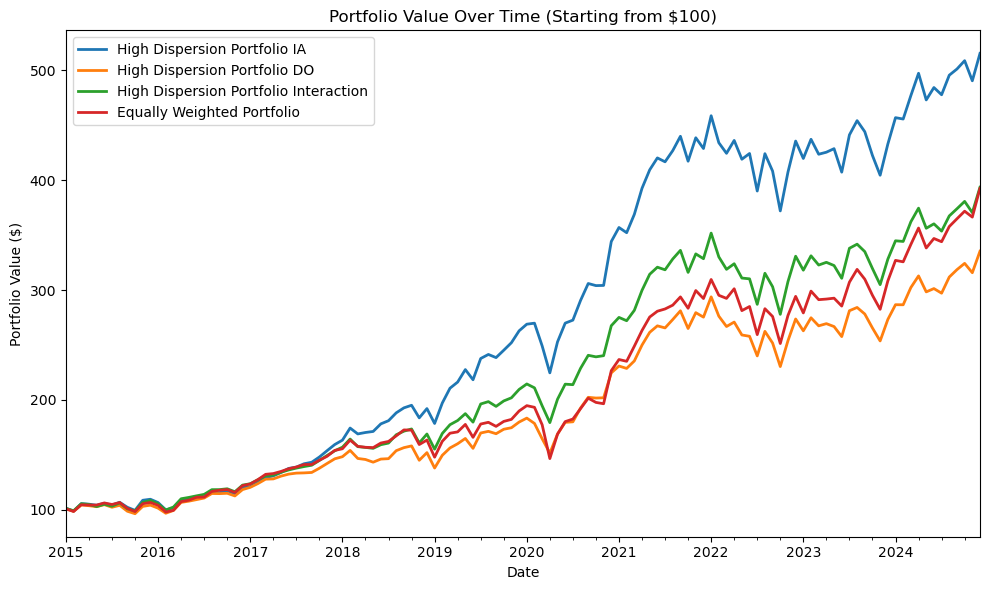

Final value (High Dispersion IA): 490.62982029327304
Final value (High Dispersion DO): 315.74552532782405
Final value (High Dispersion Interaction): 370.5001174676972
Final value (Equally Weighted): 366.4240318895379


In [ ]:
# Create a portfolio that buys all stocks in the highest 20% decile of ia_dispersion
df['ia_decile'] = df.groupby('eom')['ia_dispersion'].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates='drop')
)

df['do_decile'] = df.groupby('eom')['do_dispersion'].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates='drop')
)

df['interaction_decile'] = df.groupby('eom')['ia_do_interaction'].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates='drop')
)
# High-dispersion portfolio: top decile (decile == 4)
high_disp_port_ia = df[df['ia_decile'] == 0].groupby('eom')['ret_exc_lead1m'].mean()

high_disp_port_do = df[df['do_decile'] == 0].groupby('eom')['ret_exc_lead1m'].mean()

high_disp_port_interaction = df[df['interaction_decile'] == 0].groupby('eom')['ret_exc_lead1m'].mean()
# Equally weighted portfolio: all stocks
ew_port = df.groupby('eom')['ret_exc_lead1m'].mean()

# Portfolio evolution starting from $100
initial_value = 100
high_disp_value_ia = initial_value * (1 + high_disp_port_ia).cumprod()
high_disp_value_do = initial_value * (1 + high_disp_port_do).cumprod()
high_disp_value_interaction = initial_value * (1 + high_disp_port_interaction).cumprod()
ew_value = initial_value * (1 + ew_port).cumprod()

plt.figure(figsize=(10, 6))
high_disp_value_ia.plot(label='High Dispersion Portfolio IA', lw=2)
high_disp_value_do.plot(label='High Dispersion Portfolio DO', lw=2)
high_disp_value_interaction.plot(label='High Dispersion Portfolio Interaction', lw=2)
ew_value.plot(label='Equally Weighted Portfolio', lw=2)
plt.title('Portfolio Value Over Time (Starting from $100)')
plt.ylabel('Portfolio Value ($)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

print('Final value (Low Dispersion IA):', high_disp_value_ia.iloc[-2])
print('Final value (Low Dispersion DO):', high_disp_value_do.iloc[-2])
print('Final value (Low Dispersion Interaction):', high_disp_value_interaction.iloc[-2])
print('Final value (Equally Weighted):', ew_value.iloc[-2])